# Cacao flower microbiome (16S) — exploratory visualization

Feature table cleaned in R:
1. **Decontam** (prevalence threshold 0.55): 91 contaminant ASVs removed
2. **Off-target filter**: only `d__Bacteria`, excluding `o__Chloroplast` and `f__Mitochondria`

**Sample ID encoding:**
| part | meaning |
|---|---|
| 1st letter `c`/`p` | flower type: **c**losed / **p**ollinator-visited (open) |
| letters 2-3 | farm ID (`ib`, `kk`, `mt`, …) |
| 1st digit | tree ID on that farm |
| 2nd digit | flower replicate |
| suffix `EC`/`NC`/`PC` | extraction / negative PCR / mock community control |

**Contents:**
1. Relative abundance heatmap (top-50 ASVs, log₁₀)
2. CLR-transformed heatmap (same ASVs, diverging palette)
3. Bray-Curtis dissimilarity matrix
4. Aitchison distance matrix (Euclidean on CLR)
5. Tree-host effect: distance partitioning, PERMANOVA, Mann-Whitney U

In [1]:
from pathlib import Path

import re
import colorsys

import biom
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform
from skbio.stats.composition import clr
from skbio.stats.distance import DistanceMatrix, permanova

## Paths

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR     = PROJECT_ROOT / "results" / "biom"
METADATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR    :", DATA_DIR)
print("METADATA_DIR:", METADATA_DIR)

PROJECT_ROOT: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome
DATA_DIR    : /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/biom
METADATA_DIR: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/data


## Data loading

In [3]:
# ── Feature table ─────────────────────────────────────────────────────────────
table_16s  = biom.load_table(str(DATA_DIR / "cfm_its1_fungi_allsamples_feature-table.biom"))
sample_ids = list(table_16s.ids(axis="sample"))
print(f"Feature table: {table_16s.shape[1]} samples × {table_16s.shape[0]} ASVs")

# ── Project metadata (Excel) ──────────────────────────────────────────────────
# Row 0 is QIIME2 type hints ('#q2:types') — drop it; align to biom sample order
metadata = (
    pd.read_excel(METADATA_DIR / "sample_metadata_with_microscopy.xlsx", index_col=0)
    .iloc[1:]
    .reindex(sample_ids)          # keep only samples present in the feature table
)
metadata.index.name = "sample_id"

# Numeric columns (microscopy measurements stored as object in Excel)
_num_cols = ["dna_conc_hs_16s", "dna_conc_hs_its1",
             "pi_dic", "pi_clsm", "callose_plug_index", "fungal_colonization_score"]
for col in _num_cols:
    if col in metadata.columns:
        metadata[col] = pd.to_numeric(metadata[col], errors="coerce")

print(f"Metadata: {metadata.shape[0]} samples × {metadata.shape[1]} columns")
print(metadata["sample_type"].value_counts())

Feature table: 326 samples × 11929 ASVs
Metadata: 326 samples × 30 columns
sample_type
bagged_flower           147
unbagged_flower         147
mock_community           14
negative_pcr_control     10
extraction_control        8
Name: count, dtype: int64


In [4]:
# ── Count / relative-abundance matrices ──────────────────────────────────────
asv_ids      = list(table_16s.ids(axis="observation"))
count_df     = pd.DataFrame(table_16s.matrix_data.toarray().T, index=sample_ids, columns=asv_ids)
rel_abund_df = count_df.div(count_df.sum(axis=1), axis=0)
n_asvs_total = table_16s.shape[0]

# ── Sample-type groups (from metadata, no ID parsing needed) ──────────────────
SAMPLE_TYPE_COLORS = {
    "bagged_flower":        "#4C72B0",
    "unbagged_flower":      "#DD8452",
    "extraction_control":   "#55A868",
    "negative_pcr_control": "#C44E52",
    "mock_community":       "#8172B2",
}

groups = {
    st: metadata.index[metadata["sample_type"] == st].tolist()
    for st in SAMPLE_TYPE_COLORS
}
sample_to_group = {sid: st for st, ids in groups.items() for sid in ids}
bio_ids_all     = groups["bagged_flower"] + groups["unbagged_flower"]

# ── Colour palettes (farm & tree) ─────────────────────────────────────────────
CTRL_COLOR    = "#cccccc"
# Restrict to biological samples: controls have farm_id == sample_type in the Excel
_bio_mask     = metadata["sample_type"].isin(["bagged_flower", "unbagged_flower"])
farm_ids_uniq = sorted(metadata.loc[_bio_mask, "farm_id"].dropna().unique())
farm_palette  = dict(zip(farm_ids_uniq, sns.color_palette("Set2", len(farm_ids_uniq))))

def make_tree_palette(farm_ids_list, n_trees=7):
    pal = {}
    n_f = len(farm_ids_list)
    for i, farm in enumerate(farm_ids_list):
        hue = i / n_f
        for t in range(1, n_trees + 1):
            lightness = 0.75 - 0.45 * (t - 1) / (n_trees - 1)
            r, g, b   = colorsys.hls_to_rgb(hue, lightness, 0.72)
            pal[f"{farm}{t}"] = (r, g, b)
    return pal

tree_palette_49 = make_tree_palette(farm_ids_uniq)

def farm_color(sid):
    val = metadata.loc[sid, "farm_id"]
    return CTRL_COLOR if pd.isna(val) else farm_palette.get(val, CTRL_COLOR)

def tree_color(sid):
    tid = metadata.loc[sid, "tree_id"]
    return CTRL_COLOR if pd.isna(tid) else tree_palette_49.get(str(tid), CTRL_COLOR)

# ── Taxonomy ──────────────────────────────────────────────────────────────────
tax_df = pd.read_csv(DATA_DIR / "cfm_its1_fungi_allsamples_taxonomy.tsv", sep="\t", index_col=0)

def extract_genus(taxon):
    for part in str(taxon).split(";"):
        p = part.strip()
        if p.startswith("g__"):
            g = p[3:].strip()
            return g if g else "unclassified"
    return "unclassified"

asv_to_genus = tax_df["Taxon"].apply(extract_genus).to_dict()

N_TOP    = 50
top_asvs = rel_abund_df.mean(axis=0).nlargest(N_TOP).index
_cnt: dict = {}
genus_raw    = [asv_to_genus.get(a, "unclassified") for a in top_asvs]
final_rename = {}
for asv, g in zip(top_asvs, genus_raw):
    if genus_raw.count(g) > 1:
        _cnt[g] = _cnt.get(g, 0) + 1
        final_rename[asv] = f"{g} ({_cnt[g]})"
    else:
        final_rename[asv] = g

# ── Row annotation strips (shared across clustermap figures) ──────────────────
row_colors_all = pd.DataFrame({
    "sample type": [SAMPLE_TYPE_COLORS.get(sample_to_group.get(s, ""), CTRL_COLOR) for s in sample_ids],
    "farm":        [farm_color(s) for s in sample_ids],
    "tree":        [tree_color(s) for s in sample_ids],
}, index=sample_ids)

# ── Legend handles ────────────────────────────────────────────────────────────
_leg_stype = [Patch(facecolor=c, label=n) for n, c in SAMPLE_TYPE_COLORS.items()]
_leg_farm  = [Patch(facecolor=c, label=f) for f, c in farm_palette.items()]
_leg_tree  = [
    Patch(facecolor=tree_palette_49.get(f"{farm}{t}", CTRL_COLOR), label=f"{farm}{t}")
    for farm in farm_ids_uniq for t in range(1, 8)
] + [Patch(facecolor=CTRL_COLOR, label="control")]

_LEG_KW = dict(loc="upper center", fontsize=9, title_fontsize=10,
               framealpha=0.9, borderaxespad=0,
               columnspacing=1.0, handlelength=1.2, handletextpad=0.5)

def add_legends(fig, y0=0.965, dy=0.035):
    kw = dict(_LEG_KW, bbox_transform=fig.transFigure)
    fig.legend(handles=_leg_stype, title="sample type",
               bbox_to_anchor=(0.5, y0),        ncol=len(SAMPLE_TYPE_COLORS), **kw)
    fig.legend(handles=_leg_farm,  title="farm",
               bbox_to_anchor=(0.5, y0 - dy),   ncol=len(farm_palette),       **kw)
    fig.legend(handles=_leg_tree,  title="tree (farm+#)",
               bbox_to_anchor=(0.5, y0 - 2*dy), ncol=7,                       **kw)

def add_cbar(fig, cmap, norm, label, pos=(0.02, 0.755, 0.18, 0.006)):
    cax = fig.add_axes(list(pos))
    cb  = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                       cax=cax, orientation="horizontal")
    cb.set_label(label, fontsize=10)
    cb.ax.tick_params(labelsize=9)
    return cb

print("Setup complete.")
print(f"  bio samples : {len(bio_ids_all)}  "
      f"(bagged={len(groups['bagged_flower'])}, unbagged={len(groups['unbagged_flower'])})")
print(f"  controls    : "
      f"extraction={len(groups['extraction_control'])}, "
      f"neg_pcr={len(groups['negative_pcr_control'])}, "
      f"mock={len(groups['mock_community'])}")

Setup complete.
  bio samples : 294  (bagged=147, unbagged=147)
  controls    : extraction=8, neg_pcr=10, mock=14


## Distance matrices: BC and Aitchison

BC         mean=0.8896  range=[0.0000, 1.0000]
Aitchison  mean=172.1622  range=[0.0000, 312.3646]


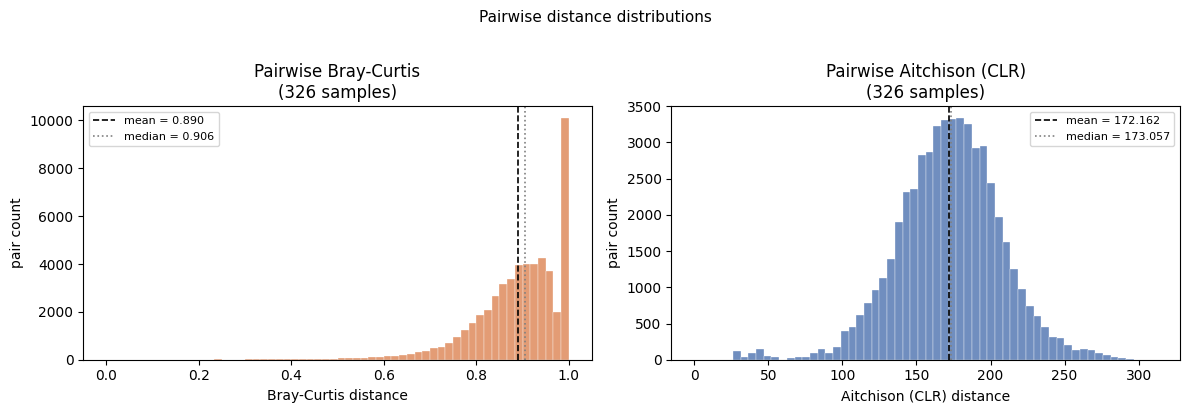

In [ ]:
# ── Bray-Curtis ───────────────────────────────────────────────────────────────
bc_condensed = pdist(rel_abund_df.values, metric="braycurtis")
bc_matrix    = squareform(bc_condensed)
bc_df        = pd.DataFrame(bc_matrix, index=sample_ids, columns=sample_ids)
bc_linkage   = linkage(bc_condensed, method="average")

# ── CLR + Aitchison ───────────────────────────────────────────────────────────
# zero replacement: multiplicative replacement method (Martín-Fernández et al. 2003)
def multiplicative_replacement(mat: np.ndarray, delta: float | None = None) -> np.ndarray:
    mat = np.asarray(mat, dtype=float)
    n   = mat.shape[1]
    if delta is None:
        # numeric stability
        delta = 1.0 / n ** 2
    result = mat.copy()

    # iterate over rows (samples; length of results matrix = number of samples)
    for i in range(len(result)):
        # zero mask for a sample i (True where value is zero, False otherwise)
        zm = result[i] == 0
        # total count of zeros in the sample i
        k  = zm.sum()
        if k:
            # multiplicative replacement: replace zeros with delta, and non-zeros are scaled down proportionally
            result[i, zm]  = delta
            result[i, ~zm] *= 1.0 - k * delta
    return result

comp = multiplicative_replacement(rel_abund_df.values)
# Centered log-ratio transformation (CLR): apply log to the ratio of each component to the geometric mean of the sample
clr_matrix          = clr(comp)
aitchison_condensed = pdist(clr_matrix, metric="euclidean")
aitchison_matrix    = squareform(aitchison_condensed)
aitchison_df        = pd.DataFrame(aitchison_matrix, index=sample_ids, columns=sample_ids)
aitchison_linkage   = linkage(aitchison_condensed, method="average")

triu_bc  = bc_matrix[np.triu_indices_from(bc_matrix, k=1)]
triu_ait = aitchison_matrix[np.triu_indices_from(aitchison_matrix, k=1)]

print(f"BC         mean={triu_bc.mean():.4f}  range=[{triu_bc.min():.4f}, {triu_bc.max():.4f}]")
print(f"Aitchison  mean={triu_ait.mean():.4f}  range=[{triu_ait.min():.4f}, {triu_ait.max():.4f}]")

# Pairwise distance distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, label, color in [
    (axes[0], triu_bc,  "Bray-Curtis",     "#DD8452"),
    (axes[1], triu_ait, "Aitchison (CLR)", "#4C72B0"),
]:
    ax.hist(vals, bins=60, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(vals.mean(),     color="black", ls="--", lw=1.2, label=f"mean = {vals.mean():.3f}")
    ax.axvline(np.median(vals), color="grey",  ls=":",  lw=1.2, label=f"median = {np.median(vals):.3f}")
    ax.set_xlabel(f"{label} distance")
    ax.set_ylabel("pair count")
    ax.set_title(f"Pairwise {label}\n({len(sample_ids)} samples)")
    ax.legend(fontsize=8)
plt.suptitle("Pairwise distance distributions", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## Relative abundance heatmap (top-50 ASVs)

Values: log₁₀(RA + 1e-6). Clustering: Euclidean distance, average linkage.

/home/nmmak/miniforge3/envs/gamma/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nmmak/miniforge3/envs/gamma/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


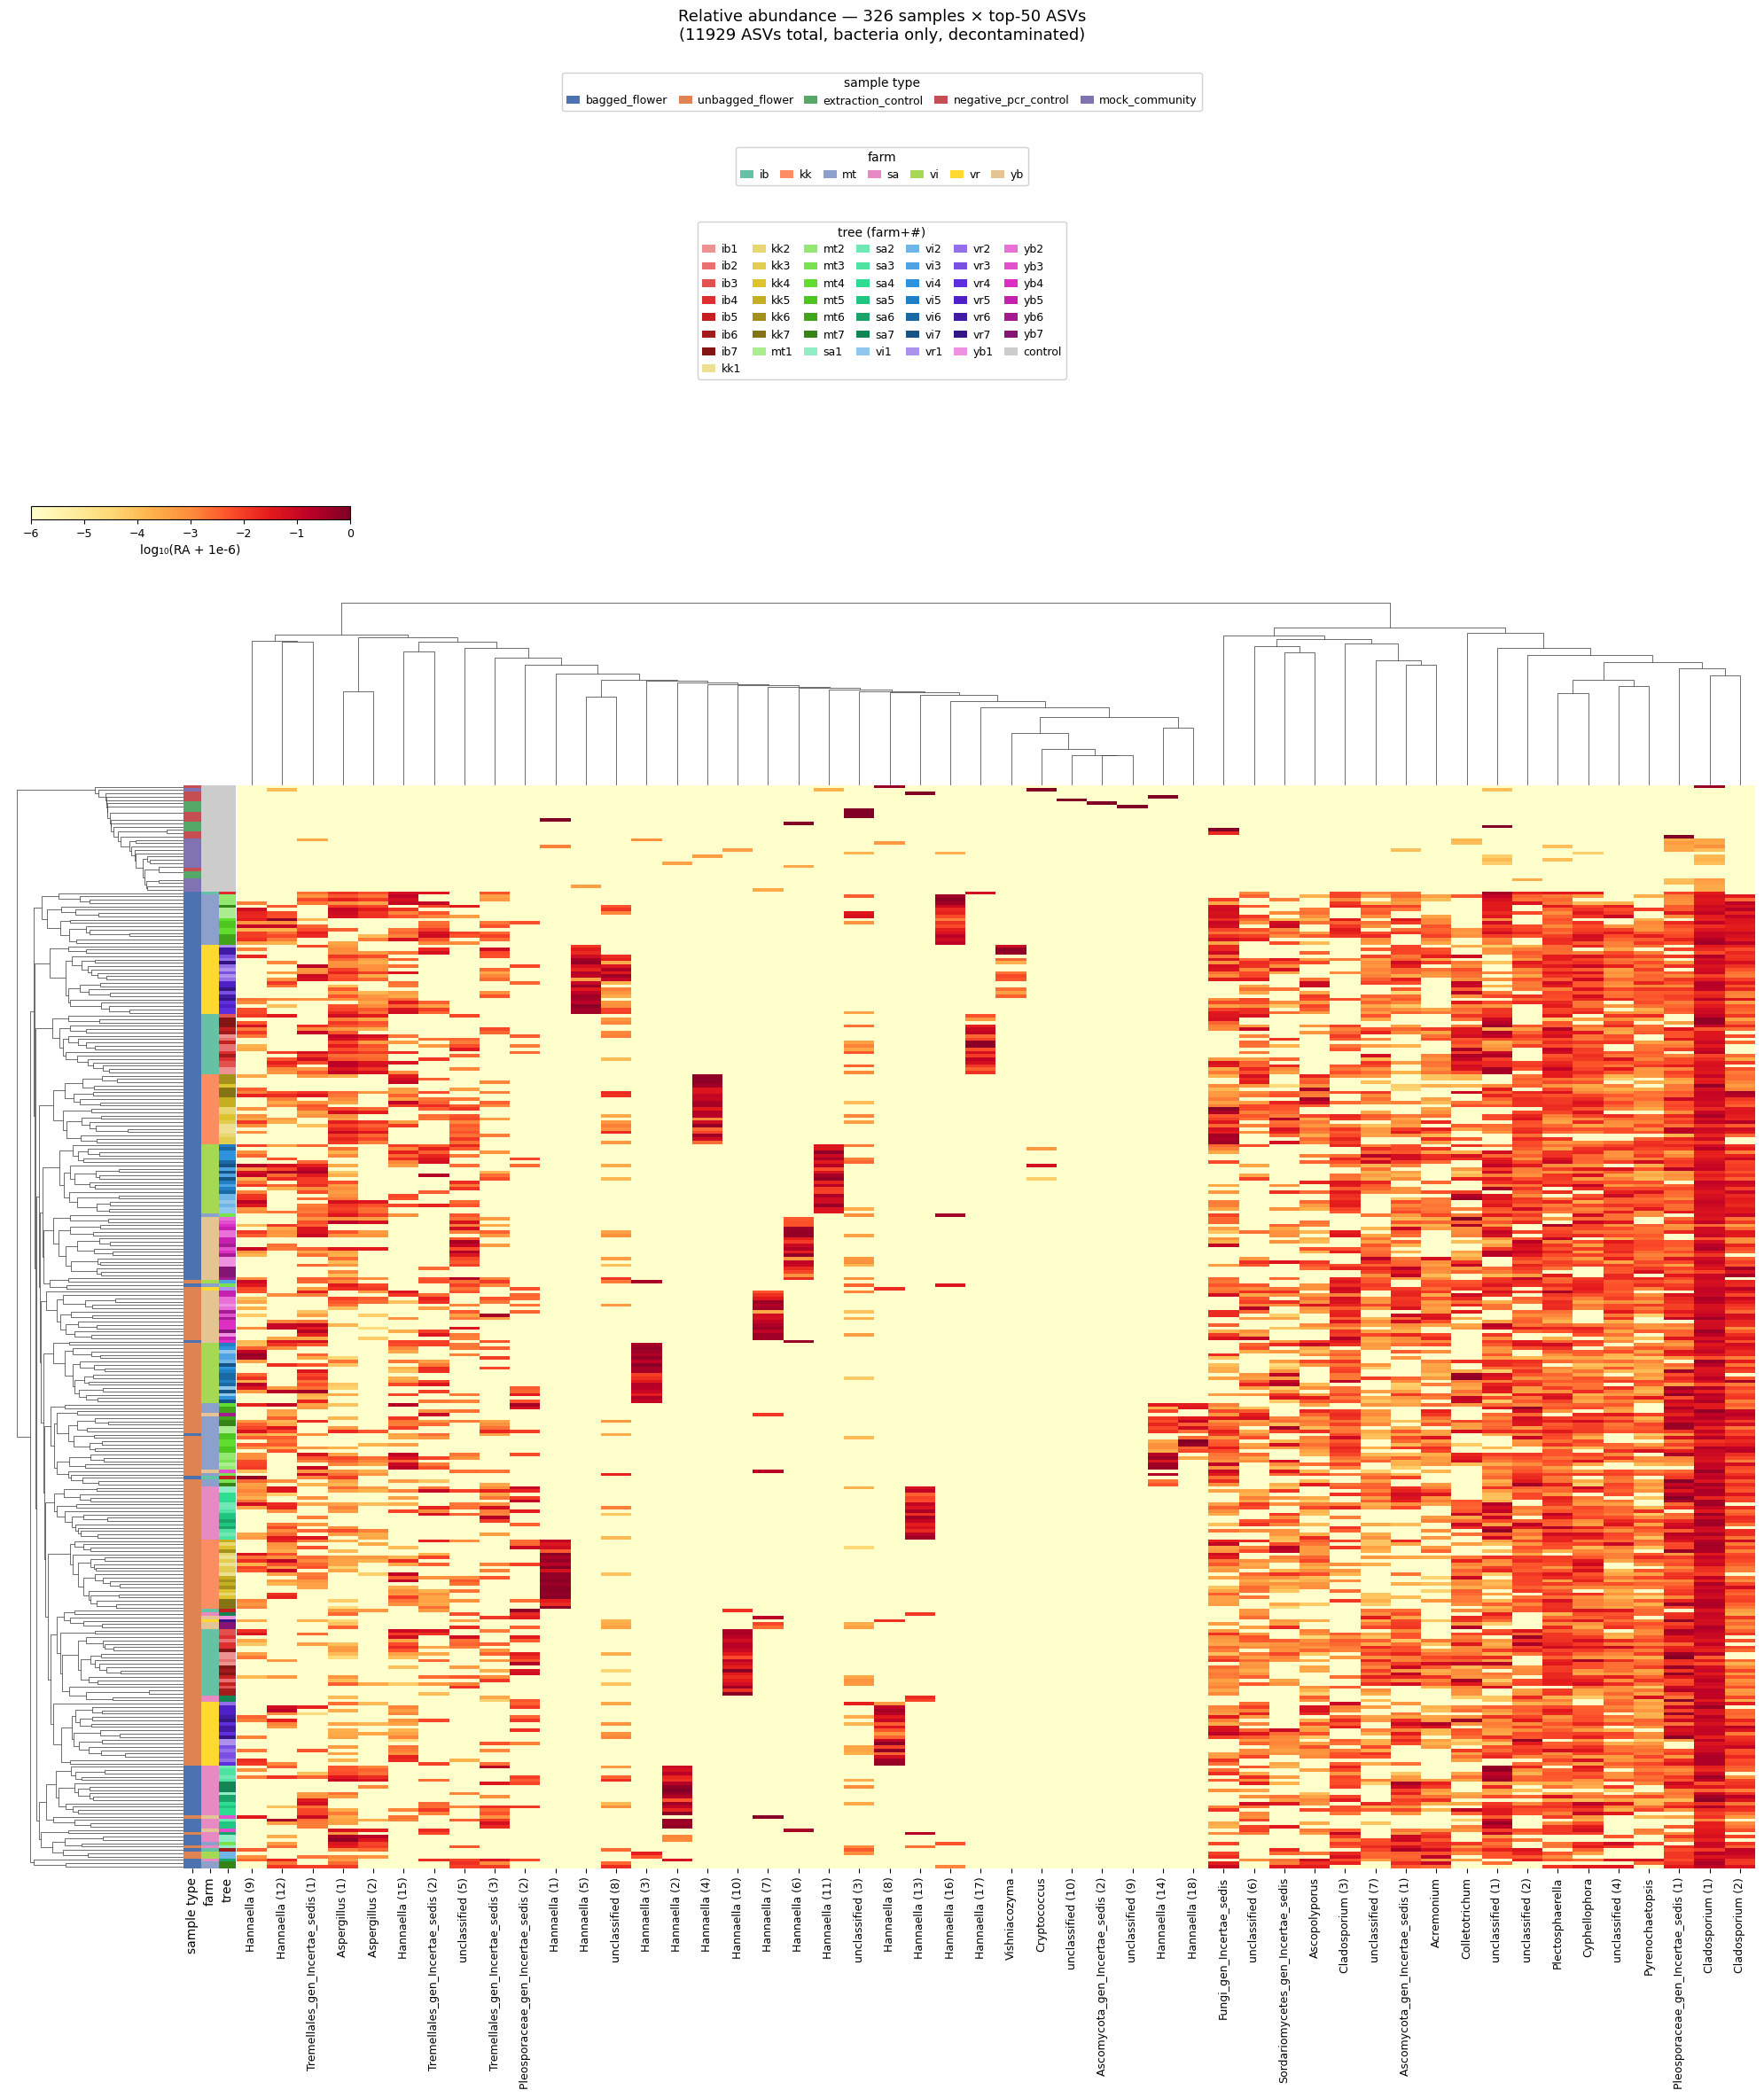

In [6]:
plot_log = np.log10(rel_abund_df[top_asvs] + 1e-6).rename(columns=final_rename)

g_ra = sns.clustermap(
    plot_log, method="average", metric="euclidean",
    row_colors=row_colors_all.loc[plot_log.index],
    figsize=(20, 24), yticklabels=False, xticklabels=True,
    cmap="YlOrRd", cbar_pos=None,
    dendrogram_ratio=(0.10, 0.15), colors_ratio=0.010,
)
g_ra.ax_heatmap.set_xticklabels(g_ra.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9)
g_ra.fig.subplots_adjust(top=0.72)
add_cbar(g_ra.fig, "YlOrRd",
         mpl.colors.Normalize(vmin=plot_log.values.min(), vmax=plot_log.values.max()),
         "log\u2081\u2080(RA + 1e-6)")
g_ra.fig.suptitle(
    f"Relative abundance \u2014 {len(sample_ids)} samples \u00d7 top-{N_TOP} ASVs\n"
    f"({n_asvs_total} ASVs total, bacteria only, decontaminated)",
    x=0.5, y=0.995, ha="center", fontsize=13)
add_legends(g_ra.fig)
plt.show()

## CLR-transformed abundance heatmap

Same top-50 ASVs, CLR-transformed. **Red** = above geometric mean, **blue** = below.  
Row order: Aitchison linkage. ASV columns: re-clustered on CLR values.

/home/nmmak/miniforge3/envs/gamma/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


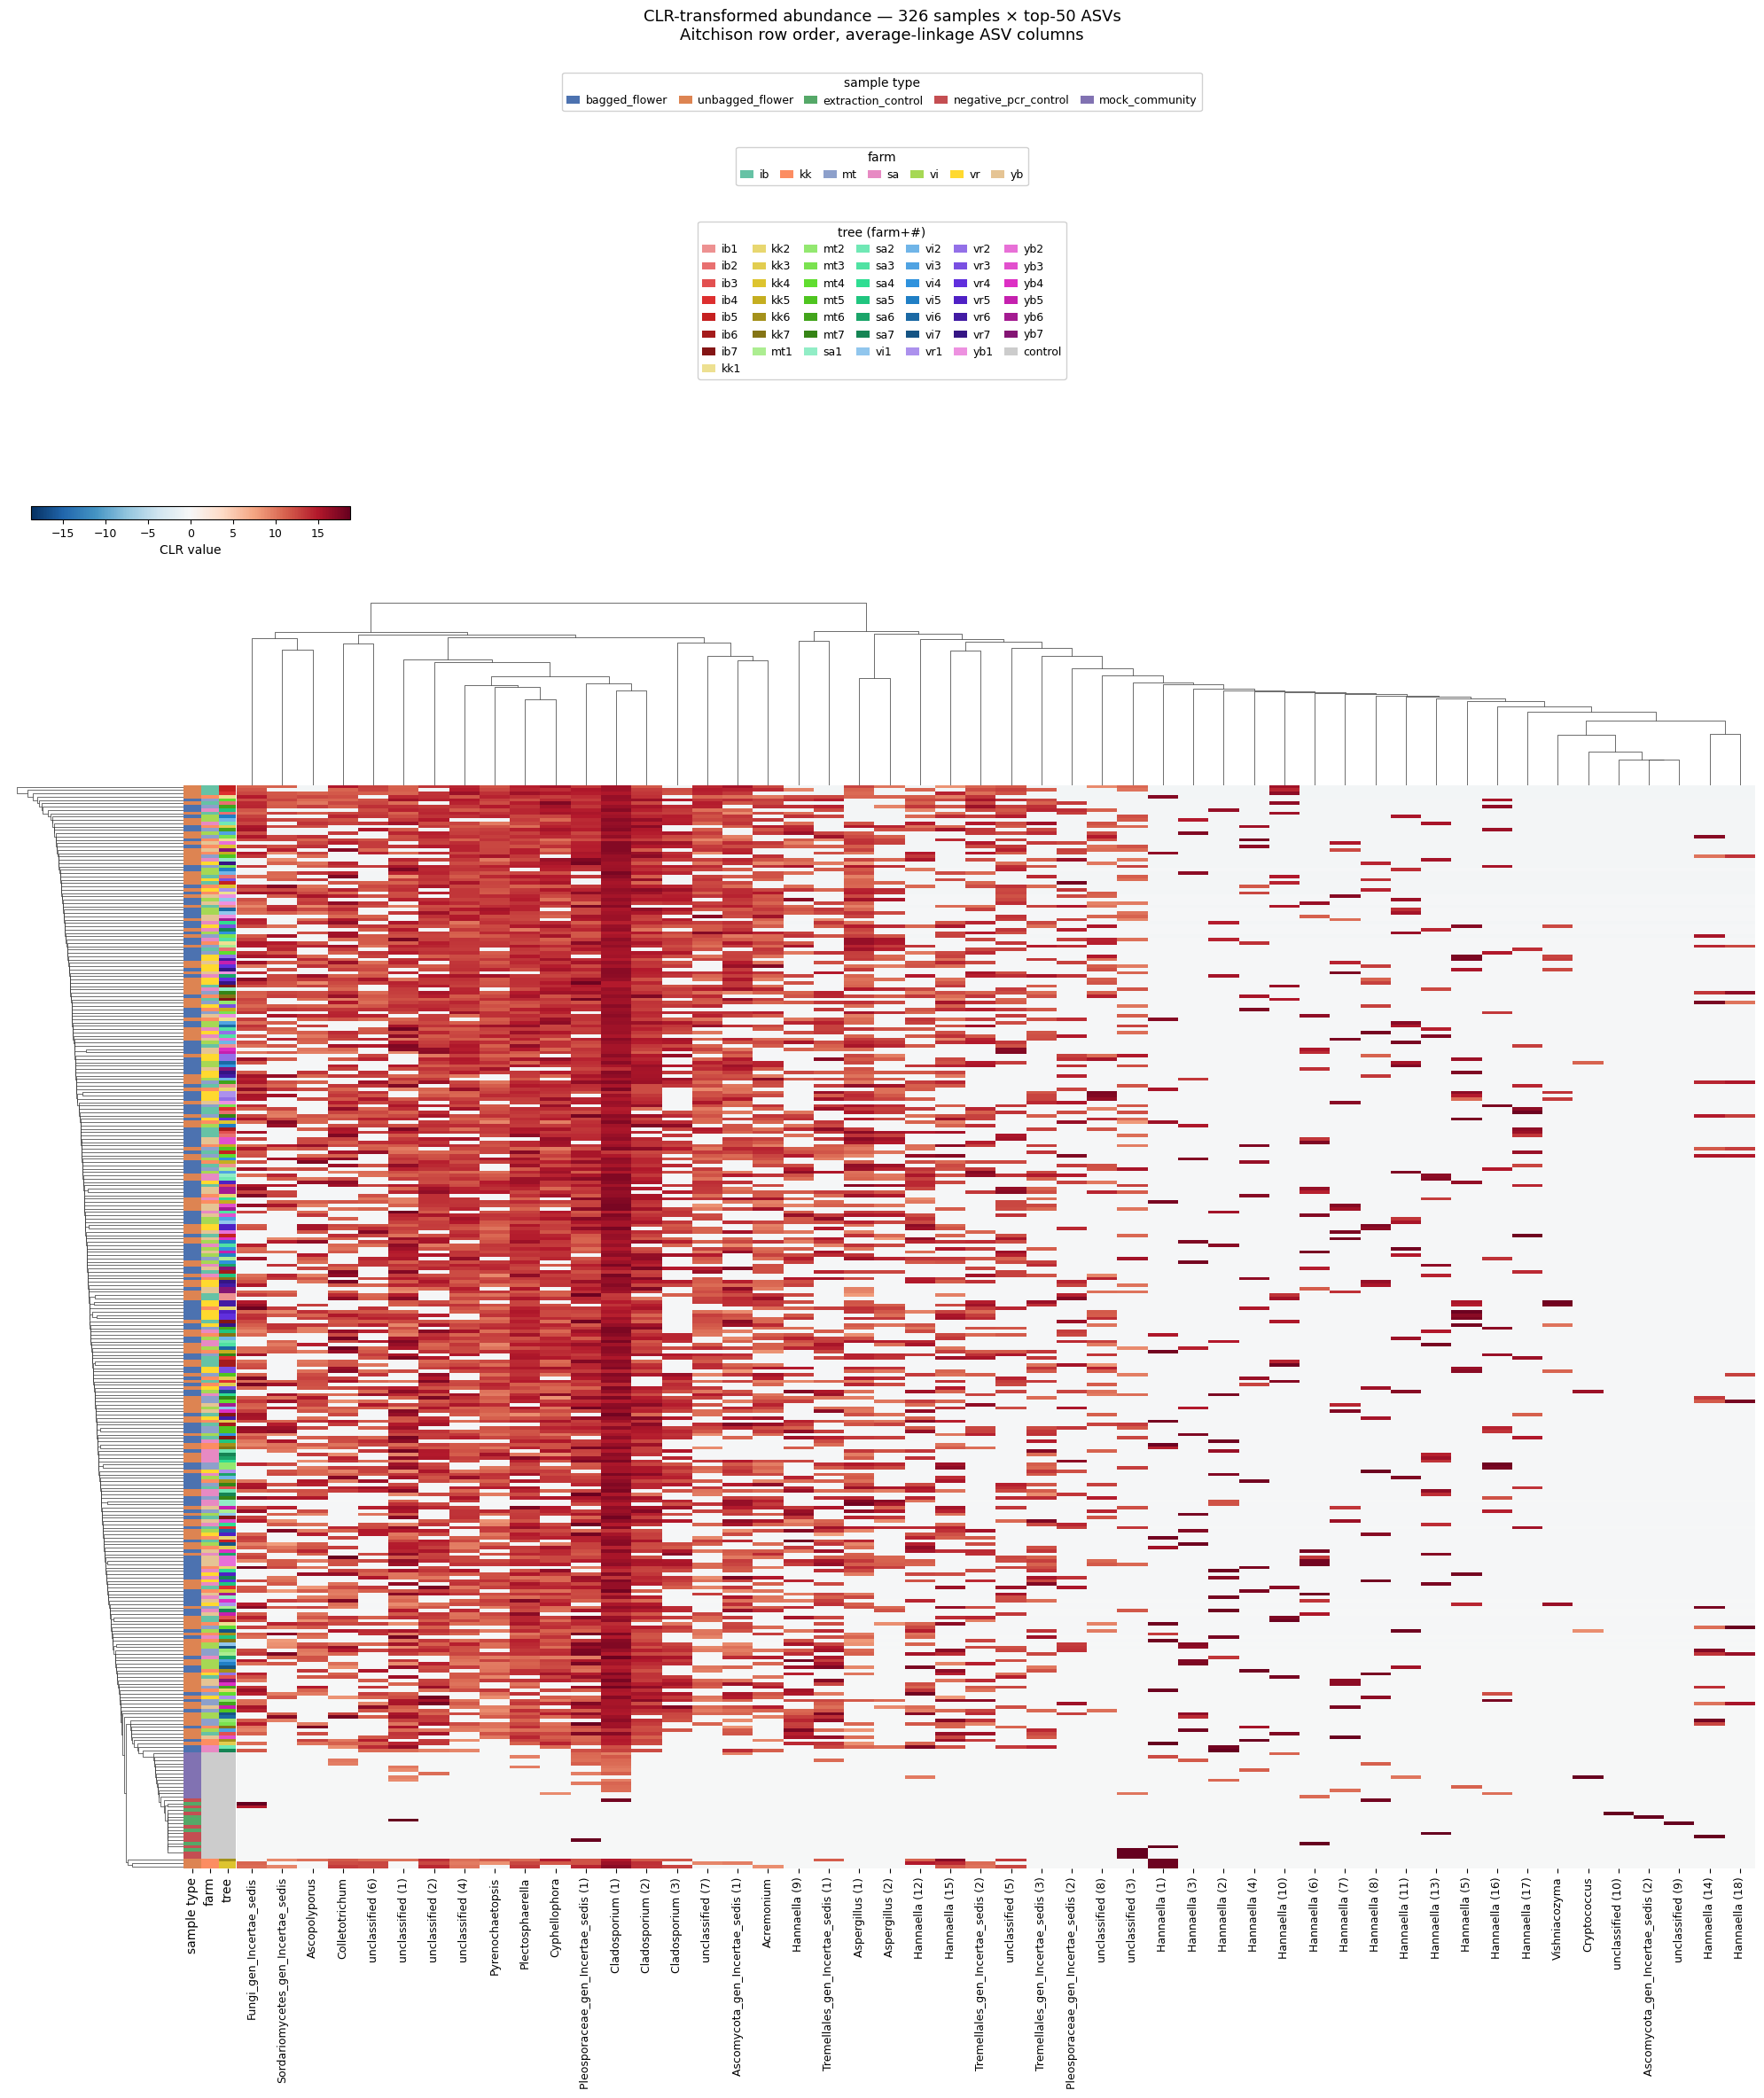

In [7]:
clr_df    = pd.DataFrame(clr_matrix, index=sample_ids, columns=asv_ids)
clr_top50 = clr_df[top_asvs].rename(columns=final_rename)

g_clr = sns.clustermap(
    clr_top50, row_linkage=aitchison_linkage, col_cluster=True,
    method="average", metric="euclidean",
    row_colors=row_colors_all.loc[clr_top50.index],
    figsize=(20, 24), yticklabels=False, xticklabels=True,
    cmap="RdBu_r", center=0, cbar_pos=None,
    dendrogram_ratio=(0.10, 0.15), colors_ratio=0.010,
)
g_clr.ax_heatmap.set_xticklabels(g_clr.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9)
g_clr.fig.subplots_adjust(top=0.72)
vmax = max(abs(clr_top50.values.min()), abs(clr_top50.values.max()))
add_cbar(g_clr.fig, "RdBu_r",
         mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
         "CLR value")
g_clr.fig.suptitle(
    f"CLR-transformed abundance \u2014 {len(sample_ids)} samples \u00d7 top-{N_TOP} ASVs\n"
    "Aitchison row order, average-linkage ASV columns",
    x=0.5, y=0.995, ha="center", fontsize=13)
add_legends(g_clr.fig)
plt.show()

## Bray-Curtis dissimilarity matrix

All samples, average linkage on precomputed distances.

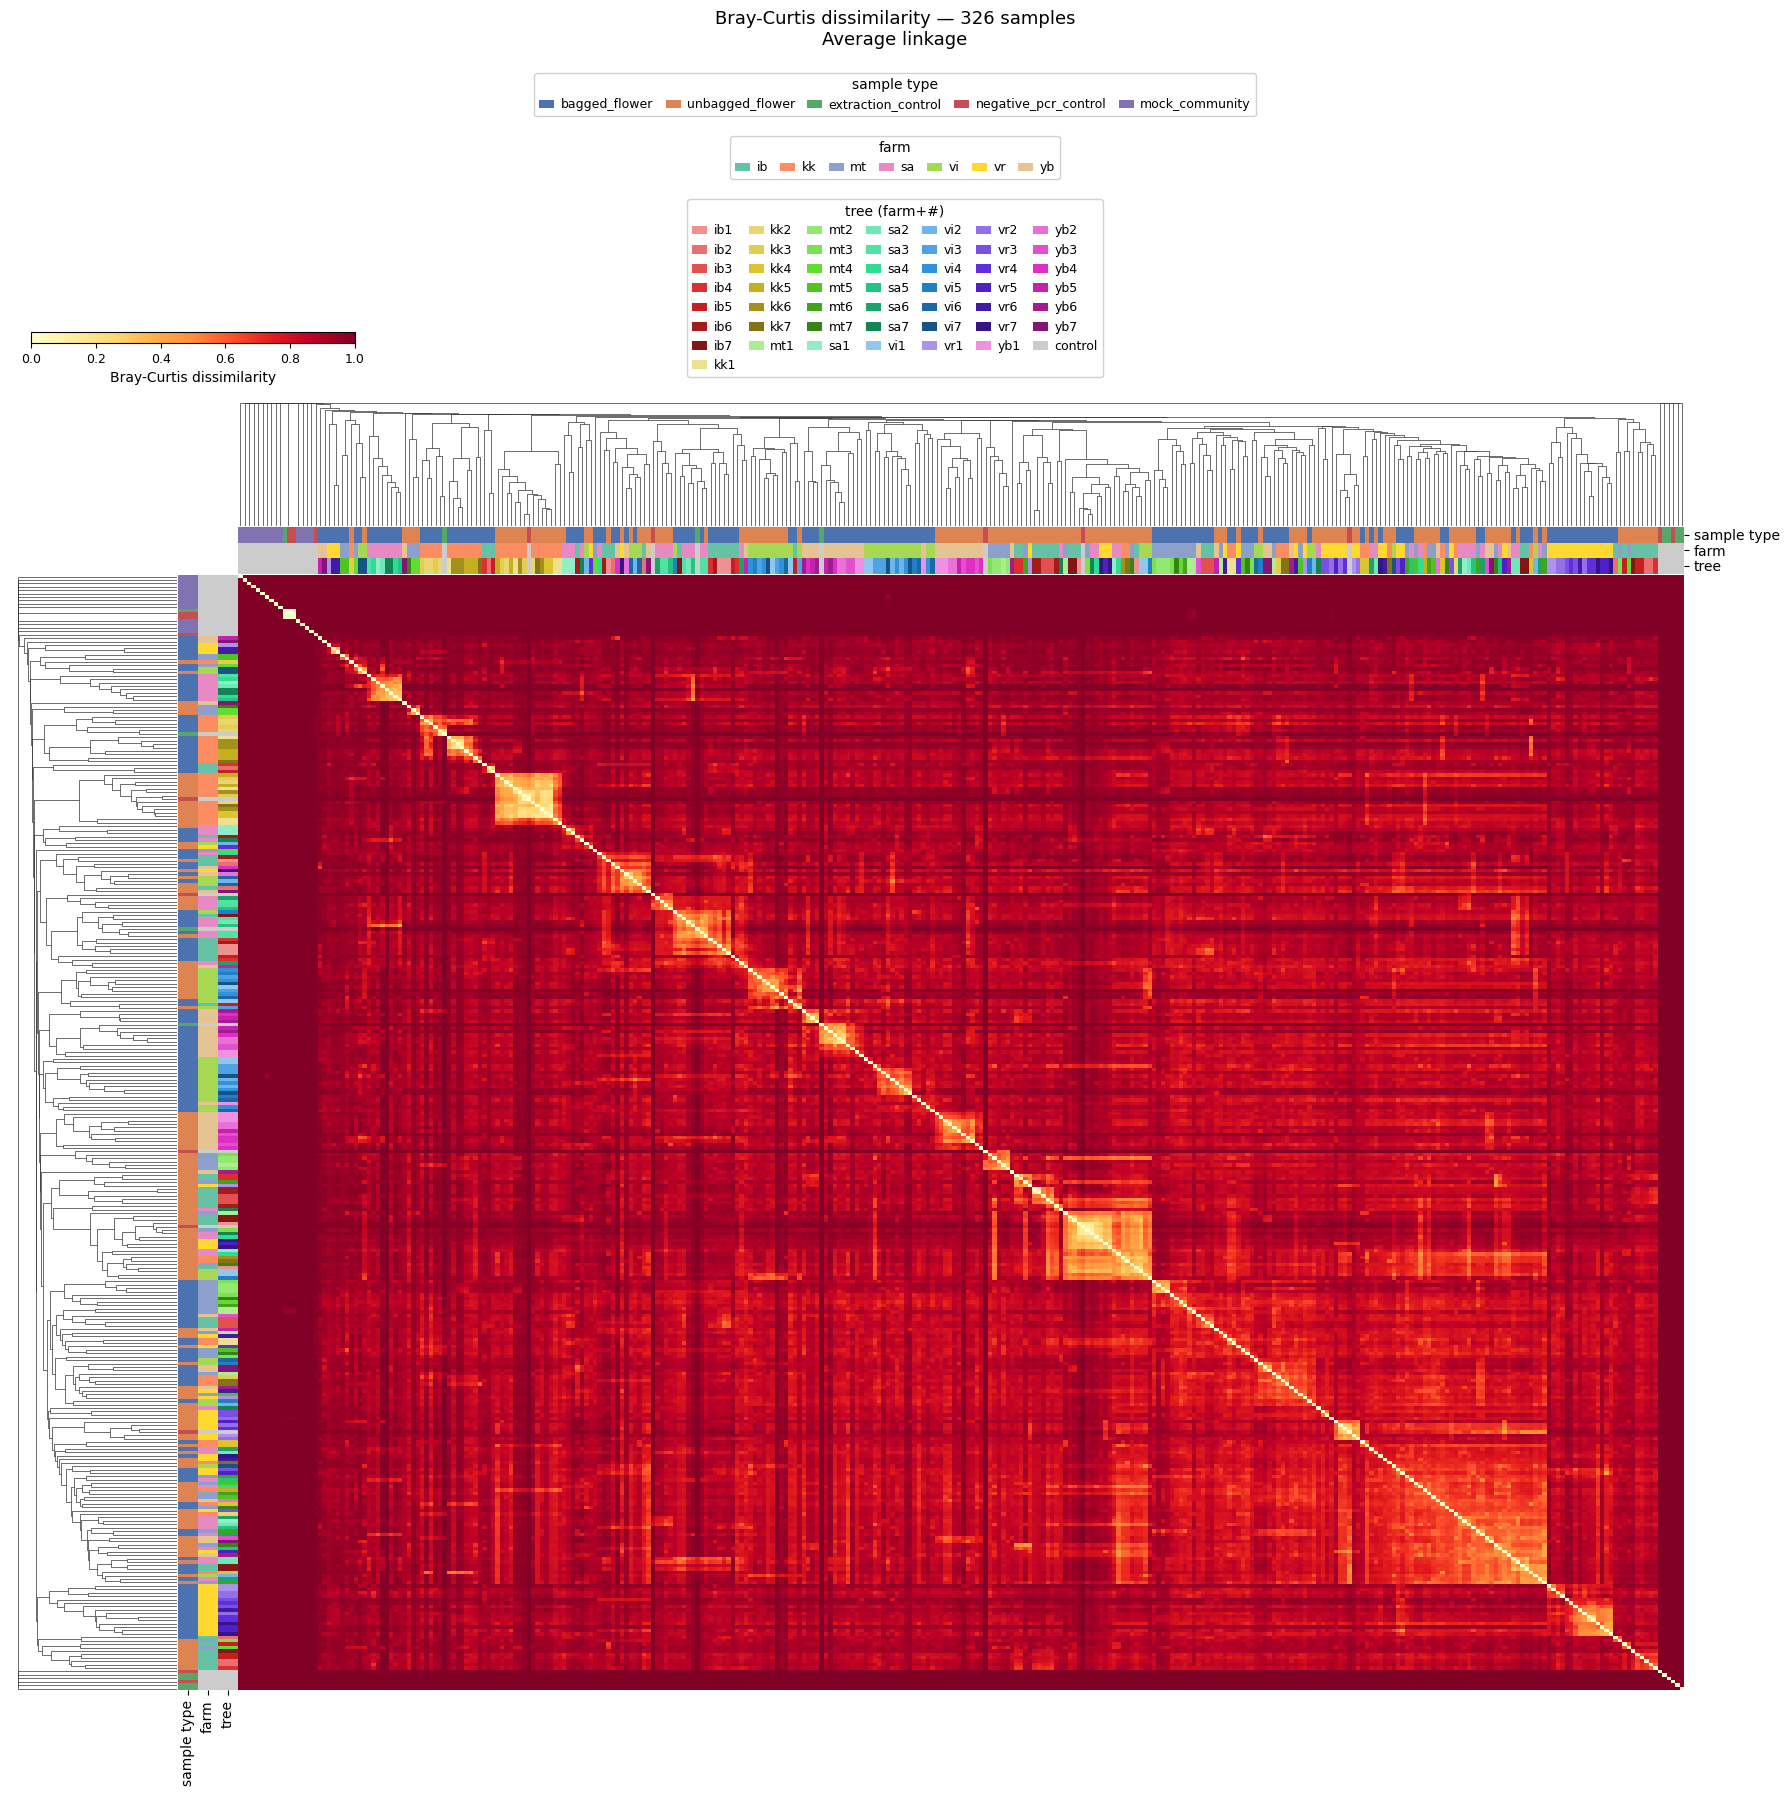

In [8]:
g_bc = sns.clustermap(
    bc_df, row_linkage=bc_linkage, col_linkage=bc_linkage,
    row_colors=row_colors_all, col_colors=row_colors_all,
    figsize=(18, 18), yticklabels=False, xticklabels=False,
    cmap="YlOrRd", cbar_pos=None, vmin=0, vmax=1,
    dendrogram_ratio=(0.10, 0.10), colors_ratio=0.012,
)
g_bc.fig.subplots_adjust(top=0.78)
add_cbar(g_bc.fig, "YlOrRd", mpl.colors.Normalize(0, 1),
         "Bray-Curtis dissimilarity", pos=(0.02, 0.81, 0.18, 0.006))
g_bc.fig.suptitle(
    f"Bray-Curtis dissimilarity \u2014 {len(sample_ids)} samples\nAverage linkage",
    x=0.5, y=0.995, ha="center", fontsize=13)
add_legends(g_bc.fig, y0=0.960)
plt.show()

## Aitchison distance matrix

Euclidean distance on CLR-transformed compositions. Zeros: multiplicative replacement.

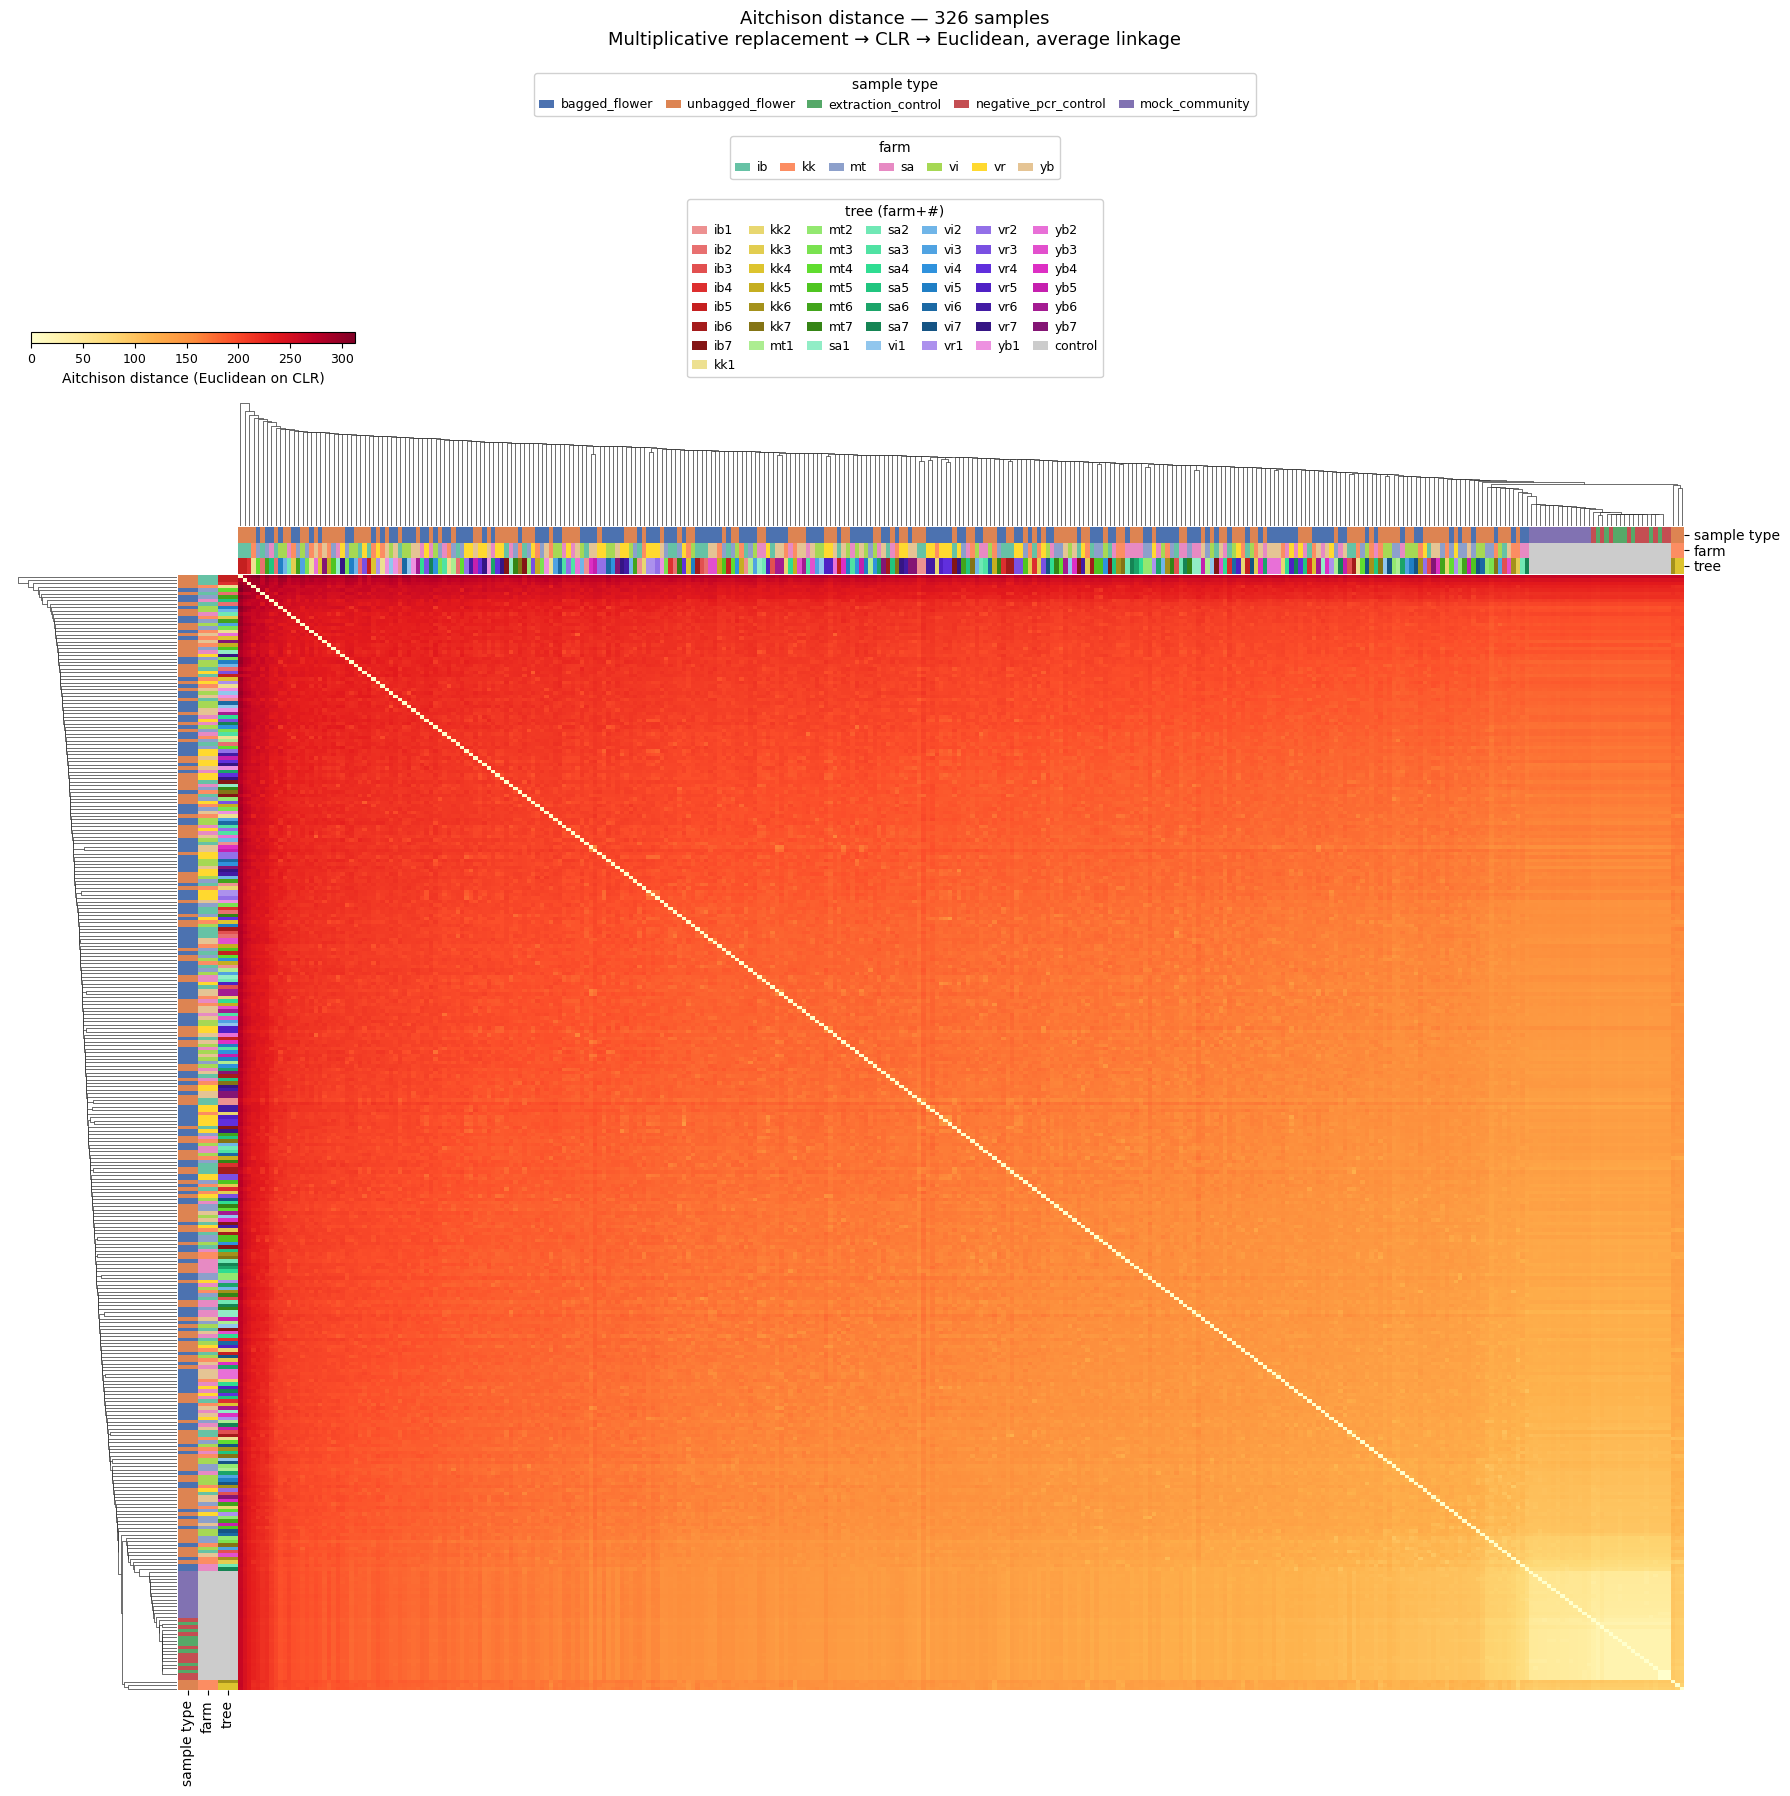

In [9]:
g_ait = sns.clustermap(
    aitchison_df, row_linkage=aitchison_linkage, col_linkage=aitchison_linkage,
    row_colors=row_colors_all, col_colors=row_colors_all,
    figsize=(18, 18), yticklabels=False, xticklabels=False,
    cmap="YlOrRd", cbar_pos=None,
    dendrogram_ratio=(0.10, 0.10), colors_ratio=0.012,
)
g_ait.fig.subplots_adjust(top=0.78)
add_cbar(g_ait.fig, "YlOrRd",
         mpl.colors.Normalize(vmin=triu_ait.min(), vmax=triu_ait.max()),
         "Aitchison distance (Euclidean on CLR)", pos=(0.02, 0.81, 0.18, 0.006))
g_ait.fig.suptitle(
    f"Aitchison distance \u2014 {len(sample_ids)} samples\n"
    "Multiplicative replacement \u2192 CLR \u2192 Euclidean, average linkage",
    x=0.5, y=0.995, ha="center", fontsize=13)
add_legends(g_ait.fig, y0=0.960)
plt.show()

## Tree (host genotype) effect on microbiome composition

If tree genotype shapes the microbiome, **within-tree** distances should be smaller than **between-tree** distances.

Distance categories:
1. **within-tree** — pairs from the same tree
2. **within-farm, between-tree** — different trees on the same farm
3. **between-farm** — trees from different farms

Tests: **PERMANOVA** (`tree_id` as grouping factor, 999 permutations) + **Mann-Whitney U** (one-tailed).

In [10]:
# ── BC sub-matrix: biological samples only ────────────────────────────────────
n_bio        = len(bio_ids_all)
bc_bio       = np.ascontiguousarray(bc_df.loc[bio_ids_all, bio_ids_all].values)
tree_ids_arr = np.array([metadata.loc[s, "tree_id"] for s in bio_ids_all])
farm_ids_arr = np.array([metadata.loc[s, "farm_id"] for s in bio_ids_all])

rows, cols = np.triu_indices(n_bio, k=1)
distances  = bc_bio[rows, cols]
same_tree  = tree_ids_arr[rows] == tree_ids_arr[cols]
same_farm  = farm_ids_arr[rows] == farm_ids_arr[cols]

dist_within_tree  = distances[same_tree]
dist_within_farm  = distances[~same_tree &  same_farm]
dist_between_farm = distances[~same_farm]

print("BC distance category       n pairs    mean      median    std")
print("-" * 62)
for label, d in [("within-tree", dist_within_tree),
                 ("within-farm, btw-tree", dist_within_farm),
                 ("between-farm", dist_between_farm)]:
    print(f"{label:28s}  {len(d):6d}   {d.mean():.4f}   {np.median(d):.4f}   {d.std():.4f}")

u1, p1 = stats.mannwhitneyu(dist_within_tree, dist_within_farm,  alternative="less")
u2, p2 = stats.mannwhitneyu(dist_within_farm, dist_between_farm, alternative="less")
print(f"\nMann-Whitney U: within-tree < within-farm   U={u1:.0f}  p={p1:.4e}")
print(f"Mann-Whitney U: within-farm < between-farm  U={u2:.0f}  p={p2:.4e}")

dm_bc      = DistanceMatrix(bc_bio, ids=bio_ids_all)
perm_bc    = permanova(dm_bc, tree_ids_arr.tolist(), permutations=999)
print(f"\n=== PERMANOVA — BC (tree_id, 999 permutations) ===")
print(perm_bc)

BC distance category       n pairs    mean      median    std
--------------------------------------------------------------
within-tree                      735   0.7870   0.8353   0.1621
within-farm, btw-tree           5292   0.8210   0.8547   0.1293
between-farm                   37044   0.8745   0.8908   0.0830

Mann-Whitney U: within-tree < within-farm   U=1745773  p=3.3531e-06
Mann-Whitney U: within-farm < between-farm  U=73128616  p=4.2052e-197

=== PERMANOVA — BC (tree_id, 999 permutations) ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     294
number of groups                 49
test statistic             2.076484
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


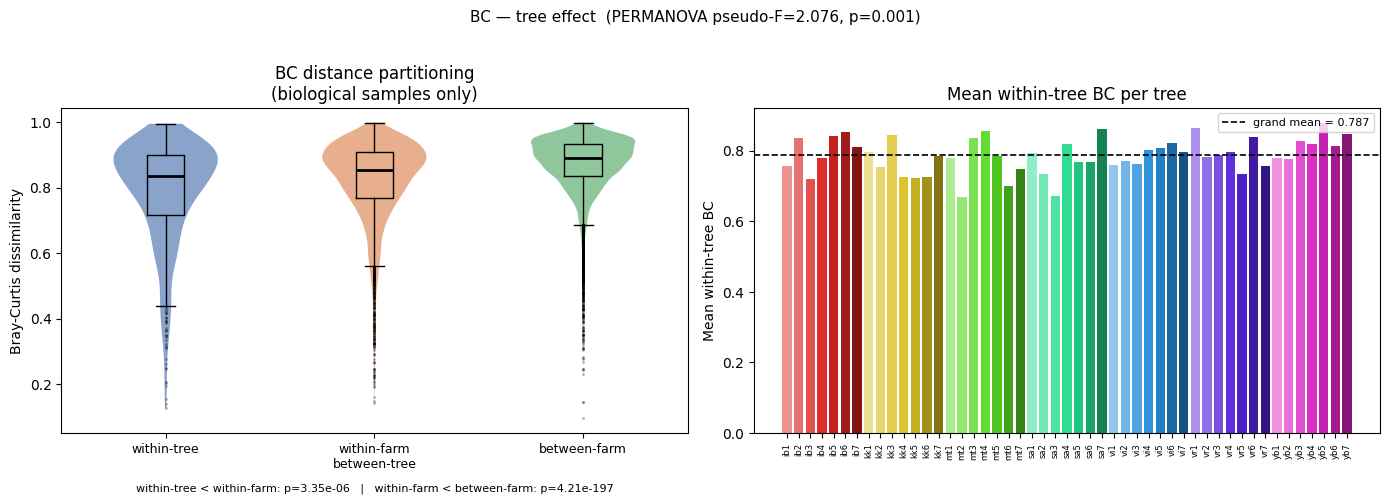

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
unique_trees = sorted(set(tree_ids_arr))

# Left: violin + box
ax = axes[0]
dist_data   = [dist_within_tree, dist_within_farm, dist_between_farm]
dist_labels = ["within-tree", "within-farm\nbetween-tree", "between-farm"]
dist_colors = ["#4C72B0", "#DD8452", "#55A868"]

parts = ax.violinplot(dist_data, positions=range(3), showmedians=False, showextrema=False)
for pc, color in zip(parts["bodies"], dist_colors):
    pc.set_facecolor(color); pc.set_alpha(0.65)
ax.boxplot(dist_data, positions=range(3), widths=0.18, patch_artist=False,
           medianprops=dict(color="black", linewidth=2),
           whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax.set_xticks(range(3))
ax.set_xticklabels(dist_labels, fontsize=9)
ax.set_ylabel("Bray-Curtis dissimilarity")
ax.set_title("BC distance partitioning\n(biological samples only)")
ax.text(0.5, -0.18, f"within-tree < within-farm: p={p1:.2e}   |   within-farm < between-farm: p={p2:.2e}",
        ha="center", transform=ax.transAxes, fontsize=8)

# Right: per-tree mean within-tree BC
ax2 = axes[1]
per_tree = [(t, bc_bio[np.ix_(idx := np.where(tree_ids_arr == t)[0],
                               idx)][np.triu_indices(len(idx), k=1)].mean())
            for t in unique_trees if len(np.where(tree_ids_arr == t)[0]) > 1]
t_labels, t_means = zip(*per_tree)
ax2.bar(range(len(t_labels)), t_means,
        color=[tree_palette_49.get(t, CTRL_COLOR) for t in t_labels], width=0.8)
ax2.axhline(dist_within_tree.mean(), color="black", ls="--", lw=1.2,
            label=f"grand mean = {dist_within_tree.mean():.3f}")
ax2.set_xticks(range(len(t_labels)))
ax2.set_xticklabels(t_labels, rotation=90, fontsize=6)
ax2.set_ylabel("Mean within-tree BC")
ax2.set_title("Mean within-tree BC per tree")
ax2.legend(fontsize=8)

plt.suptitle(f"BC — tree effect  (PERMANOVA pseudo-F={perm_bc['test statistic']:.3f}, p={perm_bc['p-value']:.3f})",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# ── Aitchison sub-matrix: biological samples only ─────────────────────────────
ait_bio = np.ascontiguousarray(aitchison_df.loc[bio_ids_all, bio_ids_all].values)
ait_dists    = ait_bio[rows, cols]
ait_within_tree  = ait_dists[same_tree]
ait_within_farm  = ait_dists[~same_tree &  same_farm]
ait_between_farm = ait_dists[~same_farm]

print("Aitchison distance category  n pairs    mean      median    std")
print("-" * 65)
for label, d in [("within-tree", ait_within_tree),
                 ("within-farm, btw-tree", ait_within_farm),
                 ("between-farm", ait_between_farm)]:
    print(f"{label:28s}  {len(d):6d}   {d.mean():.4f}   {np.median(d):.4f}   {d.std():.4f}")

u1_a, p1_a = stats.mannwhitneyu(ait_within_tree, ait_within_farm,  alternative="less")
u2_a, p2_a = stats.mannwhitneyu(ait_within_farm, ait_between_farm, alternative="less")
print(f"\nMann-Whitney U: within-tree < within-farm   U={u1_a:.0f}  p={p1_a:.4e}")
print(f"Mann-Whitney U: within-farm < between-farm  U={u2_a:.0f}  p={p2_a:.4e}")

dm_ait   = DistanceMatrix(ait_bio, ids=bio_ids_all)
perm_ait = permanova(dm_ait, tree_ids_arr.tolist(), permutations=999)
print(f"\n=== PERMANOVA — Aitchison (tree_id, 999 permutations) ===")
print(perm_ait)

print("\n── BC vs Aitchison comparison ──")
print(f"{'':30s}  {'BC':>10}  {'Aitchison':>10}")
print(f"{'pseudo-F':30s}  {perm_bc['test statistic']:>10.4f}  {perm_ait['test statistic']:>10.4f}")
print(f"{'p-value':30s}  {perm_bc['p-value']:>10.3f}  {perm_ait['p-value']:>10.3f}")

Aitchison distance category  n pairs    mean      median    std
-----------------------------------------------------------------
within-tree                      735   172.9486   172.4468   31.4227
within-farm, btw-tree           5292   176.5148   176.1051   29.7476
between-farm                   37044   180.7251   179.4799   29.8113

Mann-Whitney U: within-tree < within-farm   U=1813741  p=1.5126e-03
Mann-Whitney U: within-farm < between-farm  U=90571247  p=1.7026e-19

=== PERMANOVA — Aitchison (tree_id, 999 permutations) ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     294
number of groups                 49
test statistic              1.47831
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

── BC vs Aitchison comparison ──
                                        BC   Aitchison
pseudo-F                            2.0765      1.4783
p-value                        

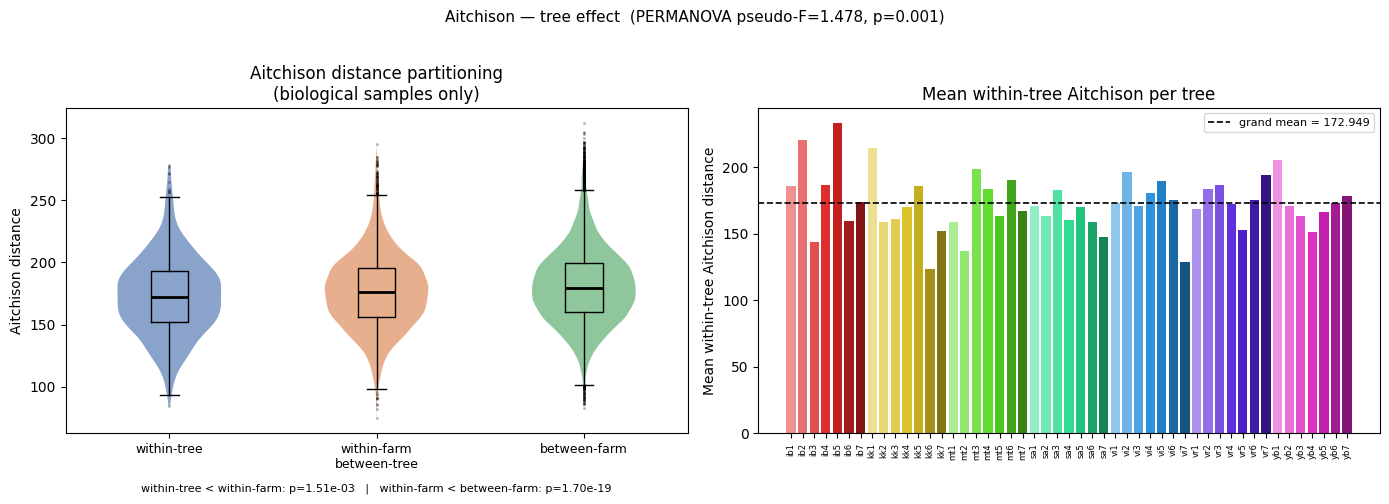

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: violin + box
ax = axes[0]
ait_data = [ait_within_tree, ait_within_farm, ait_between_farm]
parts = ax.violinplot(ait_data, positions=range(3), showmedians=False, showextrema=False)
for pc, color in zip(parts["bodies"], dist_colors):
    pc.set_facecolor(color); pc.set_alpha(0.65)
ax.boxplot(ait_data, positions=range(3), widths=0.18, patch_artist=False,
           medianprops=dict(color="black", linewidth=2),
           whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax.set_xticks(range(3))
ax.set_xticklabels(dist_labels, fontsize=9)
ax.set_ylabel("Aitchison distance")
ax.set_title("Aitchison distance partitioning\n(biological samples only)")
ax.text(0.5, -0.18, f"within-tree < within-farm: p={p1_a:.2e}   |   within-farm < between-farm: p={p2_a:.2e}",
        ha="center", transform=ax.transAxes, fontsize=8)

# Right: per-tree mean within-tree Aitchison
ax2 = axes[1]
per_tree_a = [(t, ait_bio[np.ix_(idx := np.where(tree_ids_arr == t)[0],
                                  idx)][np.triu_indices(len(idx), k=1)].mean())
              for t in unique_trees if len(np.where(tree_ids_arr == t)[0]) > 1]
t_labels_a, t_means_a = zip(*per_tree_a)
ax2.bar(range(len(t_labels_a)), t_means_a,
        color=[tree_palette_49.get(t, CTRL_COLOR) for t in t_labels_a], width=0.8)
ax2.axhline(ait_within_tree.mean(), color="black", ls="--", lw=1.2,
            label=f"grand mean = {ait_within_tree.mean():.3f}")
ax2.set_xticks(range(len(t_labels_a)))
ax2.set_xticklabels(t_labels_a, rotation=90, fontsize=6)
ax2.set_ylabel("Mean within-tree Aitchison distance")
ax2.set_title("Mean within-tree Aitchison per tree")
ax2.legend(fontsize=8)

plt.suptitle(f"Aitchison — tree effect  (PERMANOVA pseudo-F={perm_ait['test statistic']:.3f}, p={perm_ait['p-value']:.3f})",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Comparative panels: 16S vs ITS1 · all vs bio samples

In [14]:
from matplotlib import gridspec as mgs
from scipy.cluster.hierarchy import leaves_list

# ── Biological management types only (controls mirror sample_type in Excel) ──
_BIO_ST   = ("bagged_flower", "unbagged_flower")
_bio_mask = metadata["sample_type"].isin(_BIO_ST)
_mgmt_bio = sorted(metadata.loc[_bio_mask, "management_type"].dropna().unique())
MGMT_COLORS = dict(zip(_mgmt_bio, sns.color_palette("Paired", len(_mgmt_bio))))

# ── 4-column row-annotation strip ─────────────────────────────────────────────
def _row_colors4(meta):
    def _c(sid, col, pal):
        v = meta.loc[sid, col]
        return CTRL_COLOR if pd.isna(v) or v not in pal else pal[v]
    s = meta.index.tolist()
    return pd.DataFrame({
        "type": [SAMPLE_TYPE_COLORS.get(meta.loc[x, "sample_type"], CTRL_COLOR) for x in s],
        "mgmt": [_c(x, "management_type", MGMT_COLORS)   for x in s],
        "farm": [_c(x, "farm_id",          farm_palette)  for x in s],
        "tree": [_c(x, "tree_id",           tree_palette_49) for x in s],
    }, index=s)

# ── Load one BIOM dataset → dict of precomputed matrices ──────────────────────
def _load_ds(biom_path, tax_path, label):
    tbl  = biom.load_table(str(biom_path))
    sids = list(tbl.ids(axis="sample"))
    asvs = list(tbl.ids(axis="observation"))
    cnt  = pd.DataFrame(tbl.matrix_data.toarray().T, index=sids, columns=asvs)

    nz = cnt.sum(axis=1) > 0
    if (~nz).any():
        print(f"  [{label}] dropping {(~nz).sum()} zero-sum samples")
        cnt = cnt[nz];  sids = cnt.index.tolist()
    meta = metadata.reindex(sids)
    rel  = cnt.div(cnt.sum(axis=1), axis=0)

    bc_c = pdist(rel.values, metric="braycurtis")
    bc_m = squareform(bc_c);  bc_lnk = linkage(bc_c, method="average")

    comp    = multiplicative_replacement(rel.values)
    clr_arr = clr(comp)
    ait_c   = pdist(clr_arr, metric="euclidean")
    ait_m   = squareform(ait_c);  ait_lnk = linkage(ait_c, method="average")

    bio = [s for s in sids if meta.loc[s, "sample_type"] in _BIO_ST]
    top50 = (rel.loc[bio] if bio else rel).mean(axis=0).nlargest(50).index

    tax  = pd.read_csv(str(tax_path), sep="\t", index_col=0)
    a2g  = tax["Taxon"].apply(extract_genus).to_dict()
    graw = [a2g.get(a, "unclassified") for a in top50]
    _cnt, rn = {}, {}
    for asv, g in zip(top50, graw):
        if graw.count(g) > 1:
            _cnt[g] = _cnt.get(g, 0) + 1;  rn[asv] = f"{g} ({_cnt[g]})"
        else:
            rn[asv] = g

    log_top = np.log10(rel[top50] + 1e-6).rename(columns=rn)
    clr_df  = pd.DataFrame(clr_arr, index=sids, columns=asvs)
    clr_top = clr_df[top50].rename(columns=rn)
    log_clnk = linkage(pdist(log_top.T.values, metric="euclidean"), method="average")
    clr_clnk = linkage(pdist(clr_top.T.values, metric="euclidean"), method="average")

    return dict(
        label=label, sids=sids, meta=meta,
        log_top=log_top, clr_top=clr_top,
        log_clnk=log_clnk, clr_clnk=clr_clnk,
        bc_df=pd.DataFrame(bc_m,  index=sids, columns=sids), bc_lnk=bc_lnk,
        ait_df=pd.DataFrame(ait_m, index=sids, columns=sids), ait_lnk=ait_lnk,
        ait_cond=ait_c,
    )

print("Loading 4 datasets …")
_SPECS = [
    ("16S · all",  "cfm_16s_bacteria_allsamples_feature-table.biom",  "cfm_16s_bacteria_allsamples_taxonomy.tsv"),
    ("16S · bio",  "cfm_16s_bacteria_biosamples_feature-table.biom",  "cfm_16s_bacteria_biosamples_taxonomy.tsv"),
    ("ITS1 · all", "cfm_its1_fungi_allsamples_feature-table.biom",    "cfm_its1_fungi_allsamples_taxonomy.tsv"),
    ("ITS1 · bio", "cfm_its1_fungi_biosamples_feature-table.biom",    "cfm_its1_fungi_biosamples_taxonomy.tsv"),
]
DATASETS = {}
for lbl, bf, tf in _SPECS:
    print(f"  {lbl} … ", end="")
    DATASETS[lbl] = _load_ds(DATA_DIR / bf, DATA_DIR / tf, lbl)
    ds = DATASETS[lbl]
    print(f"{len(ds['sids'])} samples × {ds['log_top'].shape[1]} top ASVs")
print("Done.")


Loading 4 datasets …
  16S · all … 334 samples × 50 top ASVs
  16S · bio … 294 samples × 50 top ASVs
  ITS1 · all … 326 samples × 50 top ASVs
  ITS1 · bio … 294 samples × 50 top ASVs
Done.


In [15]:
# ── Drawing helper: one mini-heatmap in a SubplotSpec ─────────────────────────
# Rows ordered by linkage, NO dendrogram drawn (see individual panels for those).
# Col annotation: 4 strips (type, mgmt, farm, tree) left of heatmap.

def _draw_one(fig, spec, ds, mode, title):
    """Draw one ordered heatmap + 4 annotation strips inside spec."""
    if mode == "logra":
        data, rl, cl = ds["log_top"], ds["bc_lnk"], ds["log_clnk"]
        cmap = "YlOrRd"
        norm = mpl.colors.Normalize(data.values.min(), data.values.max())
        cbl  = "log₁₀(RA + 1e-6)";  show_xlbl = True
    elif mode == "clr":
        data, rl, cl = ds["clr_top"], ds["ait_lnk"], ds["clr_clnk"]
        cmap = "RdBu_r"
        vm   = max(abs(data.values.min()), abs(data.values.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vm, vcenter=0, vmax=vm)
        cbl  = "CLR value";  show_xlbl = True
    elif mode == "bc":
        data, rl, cl = ds["bc_df"], ds["bc_lnk"], ds["bc_lnk"]
        cmap = "YlOrRd";  norm = mpl.colors.Normalize(0, 1)
        cbl  = "Bray-Curtis dissimilarity";  show_xlbl = False
    else:  # aitchison
        data, rl, cl = ds["ait_df"], ds["ait_lnk"], ds["ait_lnk"]
        tv   = ds["ait_df"].values[np.triu_indices(len(ds["sids"]), k=1)]
        cmap = "YlOrRd";  norm = mpl.colors.Normalize(tv.min(), tv.max())
        cbl  = "Aitchison distance";  show_xlbl = False

    ro = leaves_list(rl);  co = leaves_list(cl)
    dr = data.iloc[ro].iloc[:, co]
    rc = _row_colors4(ds["meta"]).iloc[ro]

    # Layout: [title row] / [4 strips | heatmap row]
    gs = mgs.GridSpecFromSubplotSpec(
        2, 5, subplot_spec=spec,
        width_ratios=[0.022, 0.022, 0.022, 0.022, 0.912],
        height_ratios=[0.05, 0.95],
        hspace=0.02, wspace=0.008,
    )
    ax_ttl = fig.add_subplot(gs[0, :]);  ax_ttl.axis("off")
    ax_ttl.text(0.5, 0.3, title, ha="center", va="center",
                fontsize=9, fontweight="bold", transform=ax_ttl.transAxes)

    strip_labels = ["type", "mgmt", "farm", "tree"]
    for j, (col_name, slbl) in enumerate(zip(rc.columns, strip_labels)):
        ax_c = fig.add_subplot(gs[1, j])
        arr  = np.array([[mpl.colors.to_rgb(c)] for c in rc[col_name]])
        ax_c.imshow(arr, aspect="auto", origin="upper",
                    extent=[0, 1, len(arr), 0], interpolation="none")
        ax_c.set_yticks([]);  ax_c.set_xticks([0.5])
        ax_c.set_xticklabels([slbl], rotation=90, fontsize=6)
        for sp in ax_c.spines.values():  sp.set_visible(False)

    ax_ht = fig.add_subplot(gs[1, 4])
    img   = ax_ht.pcolormesh(dr.values, cmap=cmap, norm=norm, rasterized=True)
    ax_ht.set_yticks([]);  ax_ht.invert_yaxis()
    if show_xlbl:
        ax_ht.set_xticks(np.arange(dr.shape[1]) + 0.5)
        ax_ht.set_xticklabels(list(dr.columns), rotation=90, fontsize=5)
    else:
        ax_ht.set_xticks([])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                      ax=ax_ht, location="top", fraction=0.04, pad=0.02)
    cb.set_label(cbl, fontsize=7);  cb.ax.tick_params(labelsize=6)
    return img

# ── Shared legend for each panel ───────────────────────────────────────────────
def _draw_legend(ax):
    ax.axis("off")
    P = Patch

    def _leg(handles, title, anchor, ncol, fs=7):
        l = ax.legend(handles=handles, title=title,
                      loc="upper left", bbox_to_anchor=anchor,
                      bbox_transform=ax.transAxes, ncol=ncol,
                      framealpha=0, fontsize=fs, title_fontsize=fs+1,
                      handlelength=1.0, handletextpad=0.4, columnspacing=0.7)
        ax.add_artist(l)

    _leg([P(fc=c, label=n, lw=0) for n, c in SAMPLE_TYPE_COLORS.items()],
         "sample type", (0.0, 1.00), len(SAMPLE_TYPE_COLORS))

    _leg([P(fc=c, label=n, lw=0) for n, c in MGMT_COLORS.items()]
         + [P(fc=CTRL_COLOR, label="control", lw=0)],
         "management", (0.0, 0.72), len(MGMT_COLORS) + 1)

    _leg([P(fc=c, label=n, lw=0) for n, c in farm_palette.items()]
         + [P(fc=CTRL_COLOR, label="control", lw=0)],
         "farm", (0.0, 0.50), len(farm_palette) + 1)

    tr_h = [P(fc=tree_palette_49.get(f"{fm}{t}", CTRL_COLOR), label=f"{fm}{t}", lw=0)
            for fm in farm_ids_uniq for t in range(1, 8)]
    tr_h += [P(fc=CTRL_COLOR, label="control", lw=0)]
    _leg(tr_h, "tree (farm+#)", (0.0, 0.28), 8, fs=6)

_DS_ORDER  = list(DATASETS.keys())
_DS_TITLES = ["16S — all samples", "16S — bio only",
              "ITS1 — all samples", "ITS1 — bio only"]
print("Helpers ready.")


Helpers ready.


### Panel 1 — Relative abundance (log₁₀ RA + 1e-6) · top-50 ASVs

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_01_logra.png


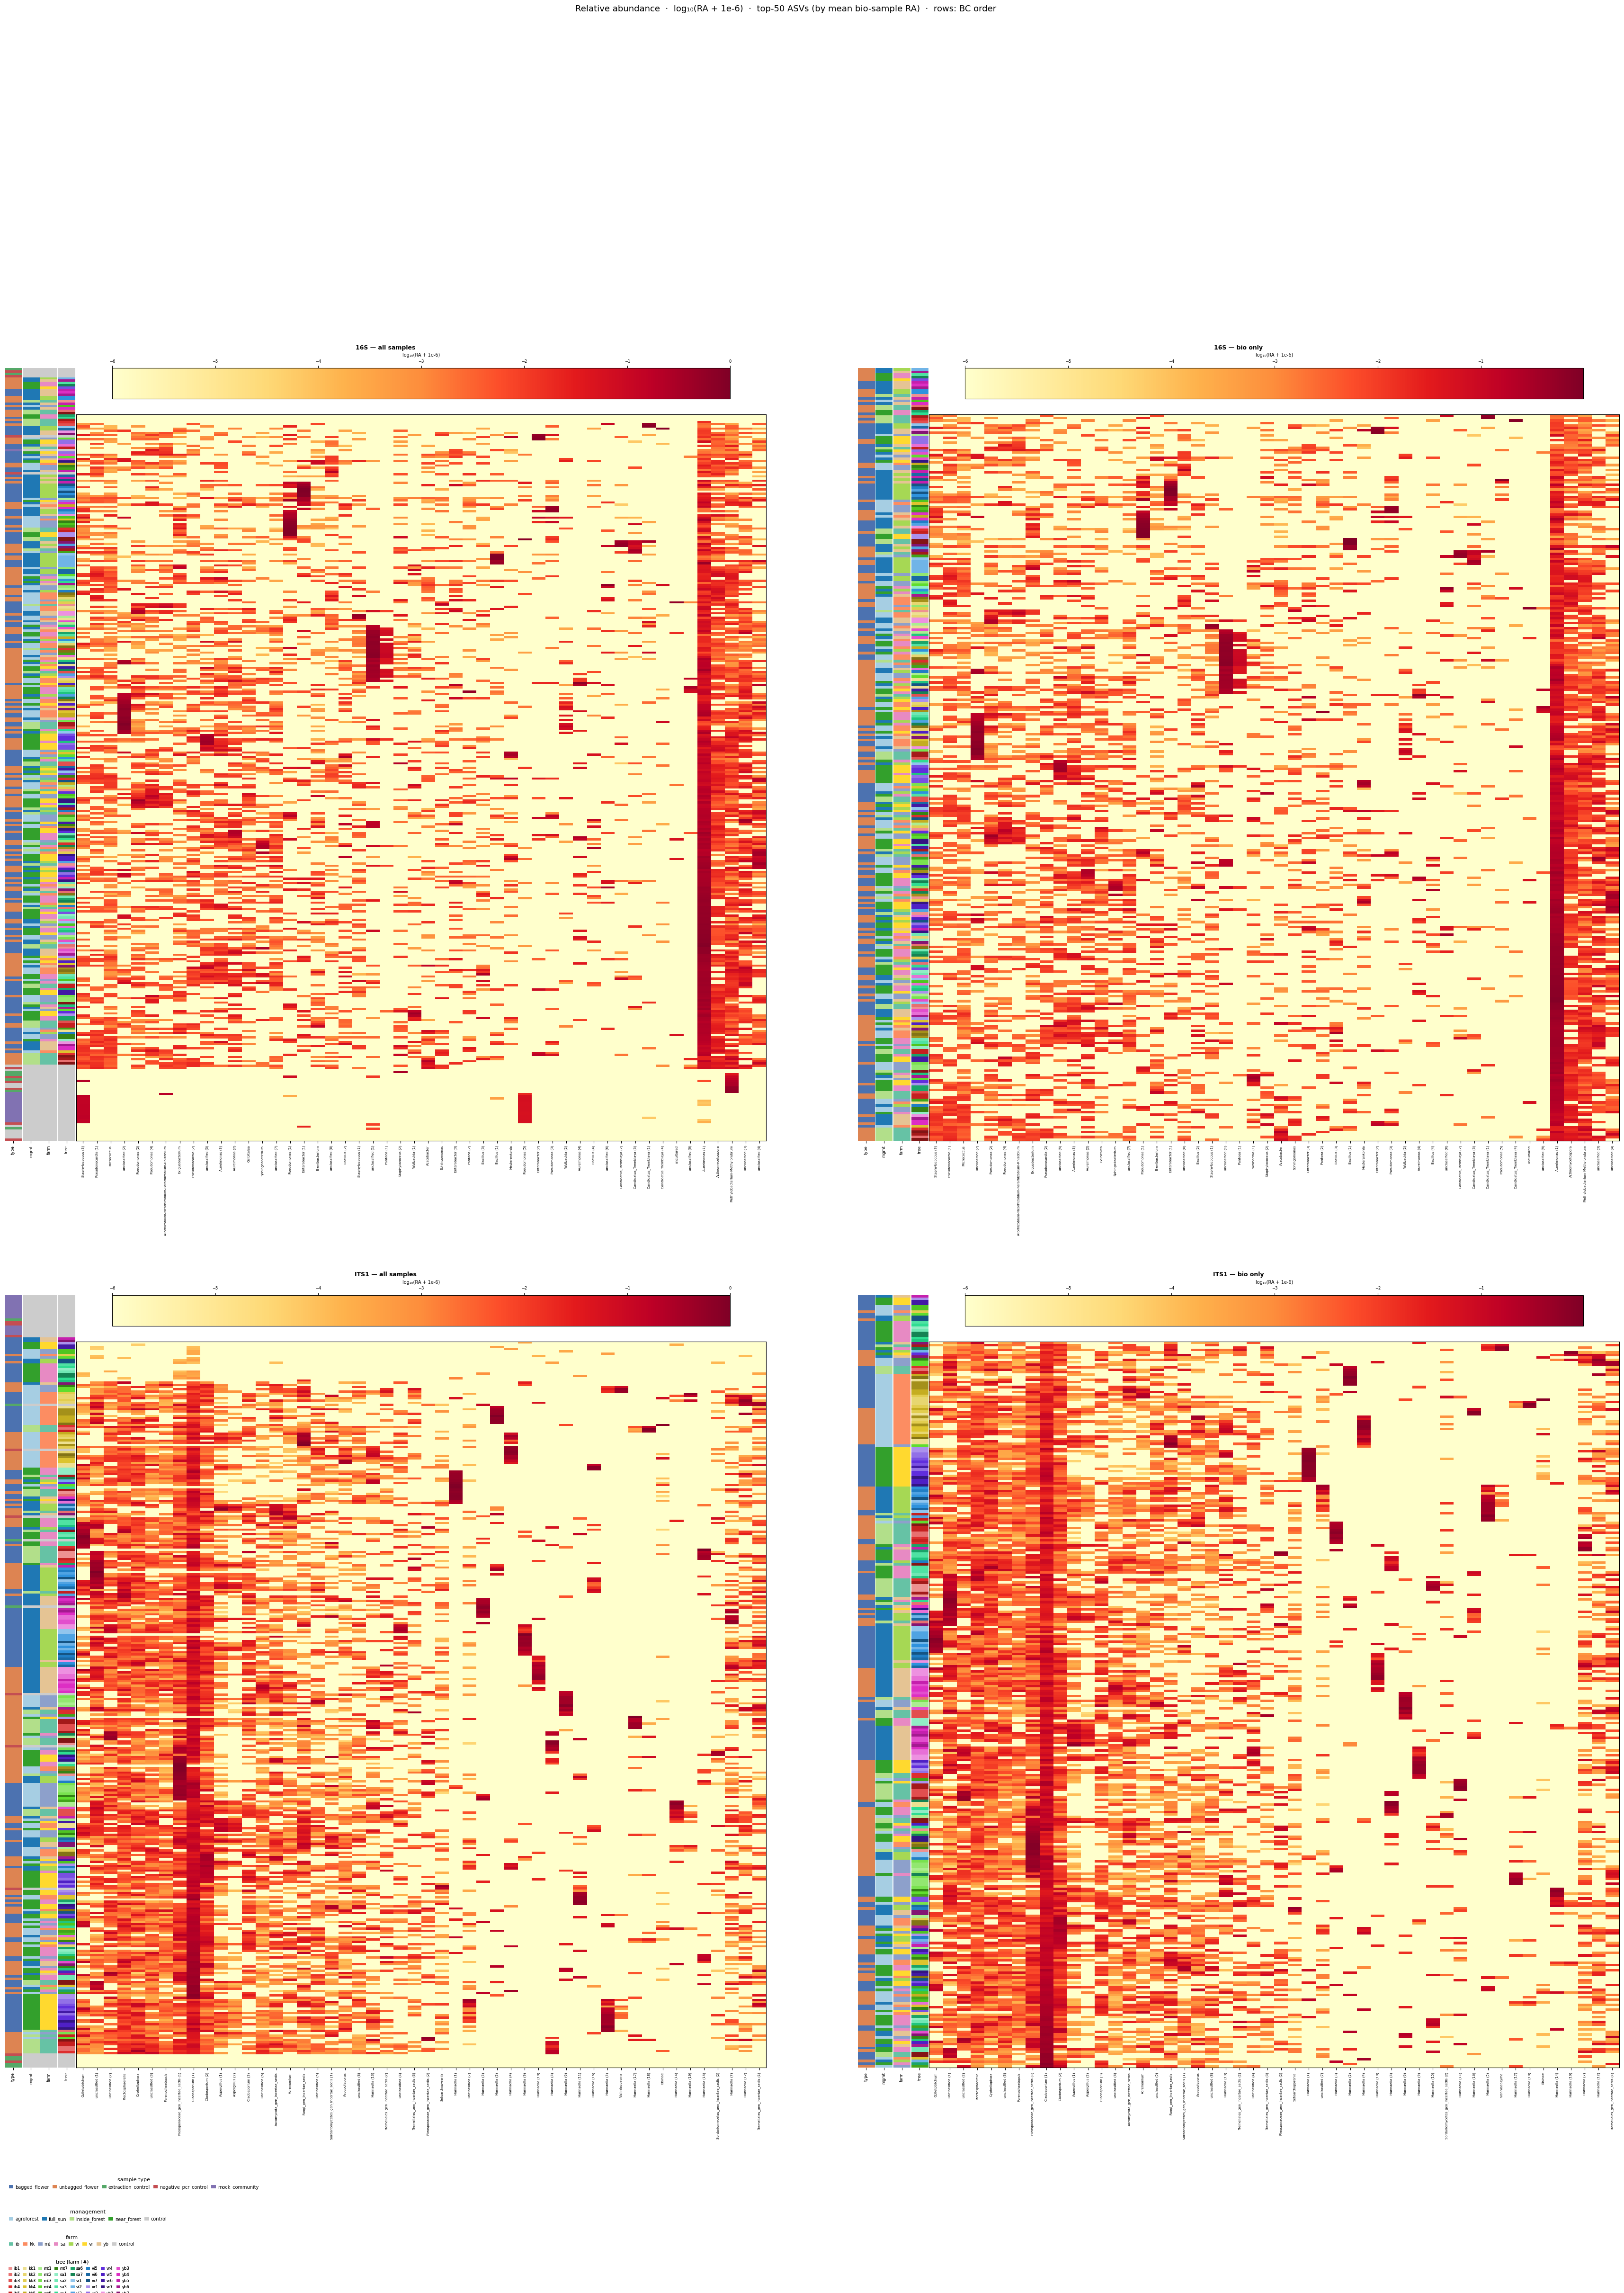

In [16]:
_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "logra", _ttl)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg)

_fig.suptitle("Relative abundance  ·  log₁₀(RA + 1e-6)  ·  top-50 ASVs (by mean bio-sample RA)  ·  rows: BC order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_01_logra.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()


### Panel 2 — CLR-transformed abundance · top-50 ASVs

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_02_clr.png


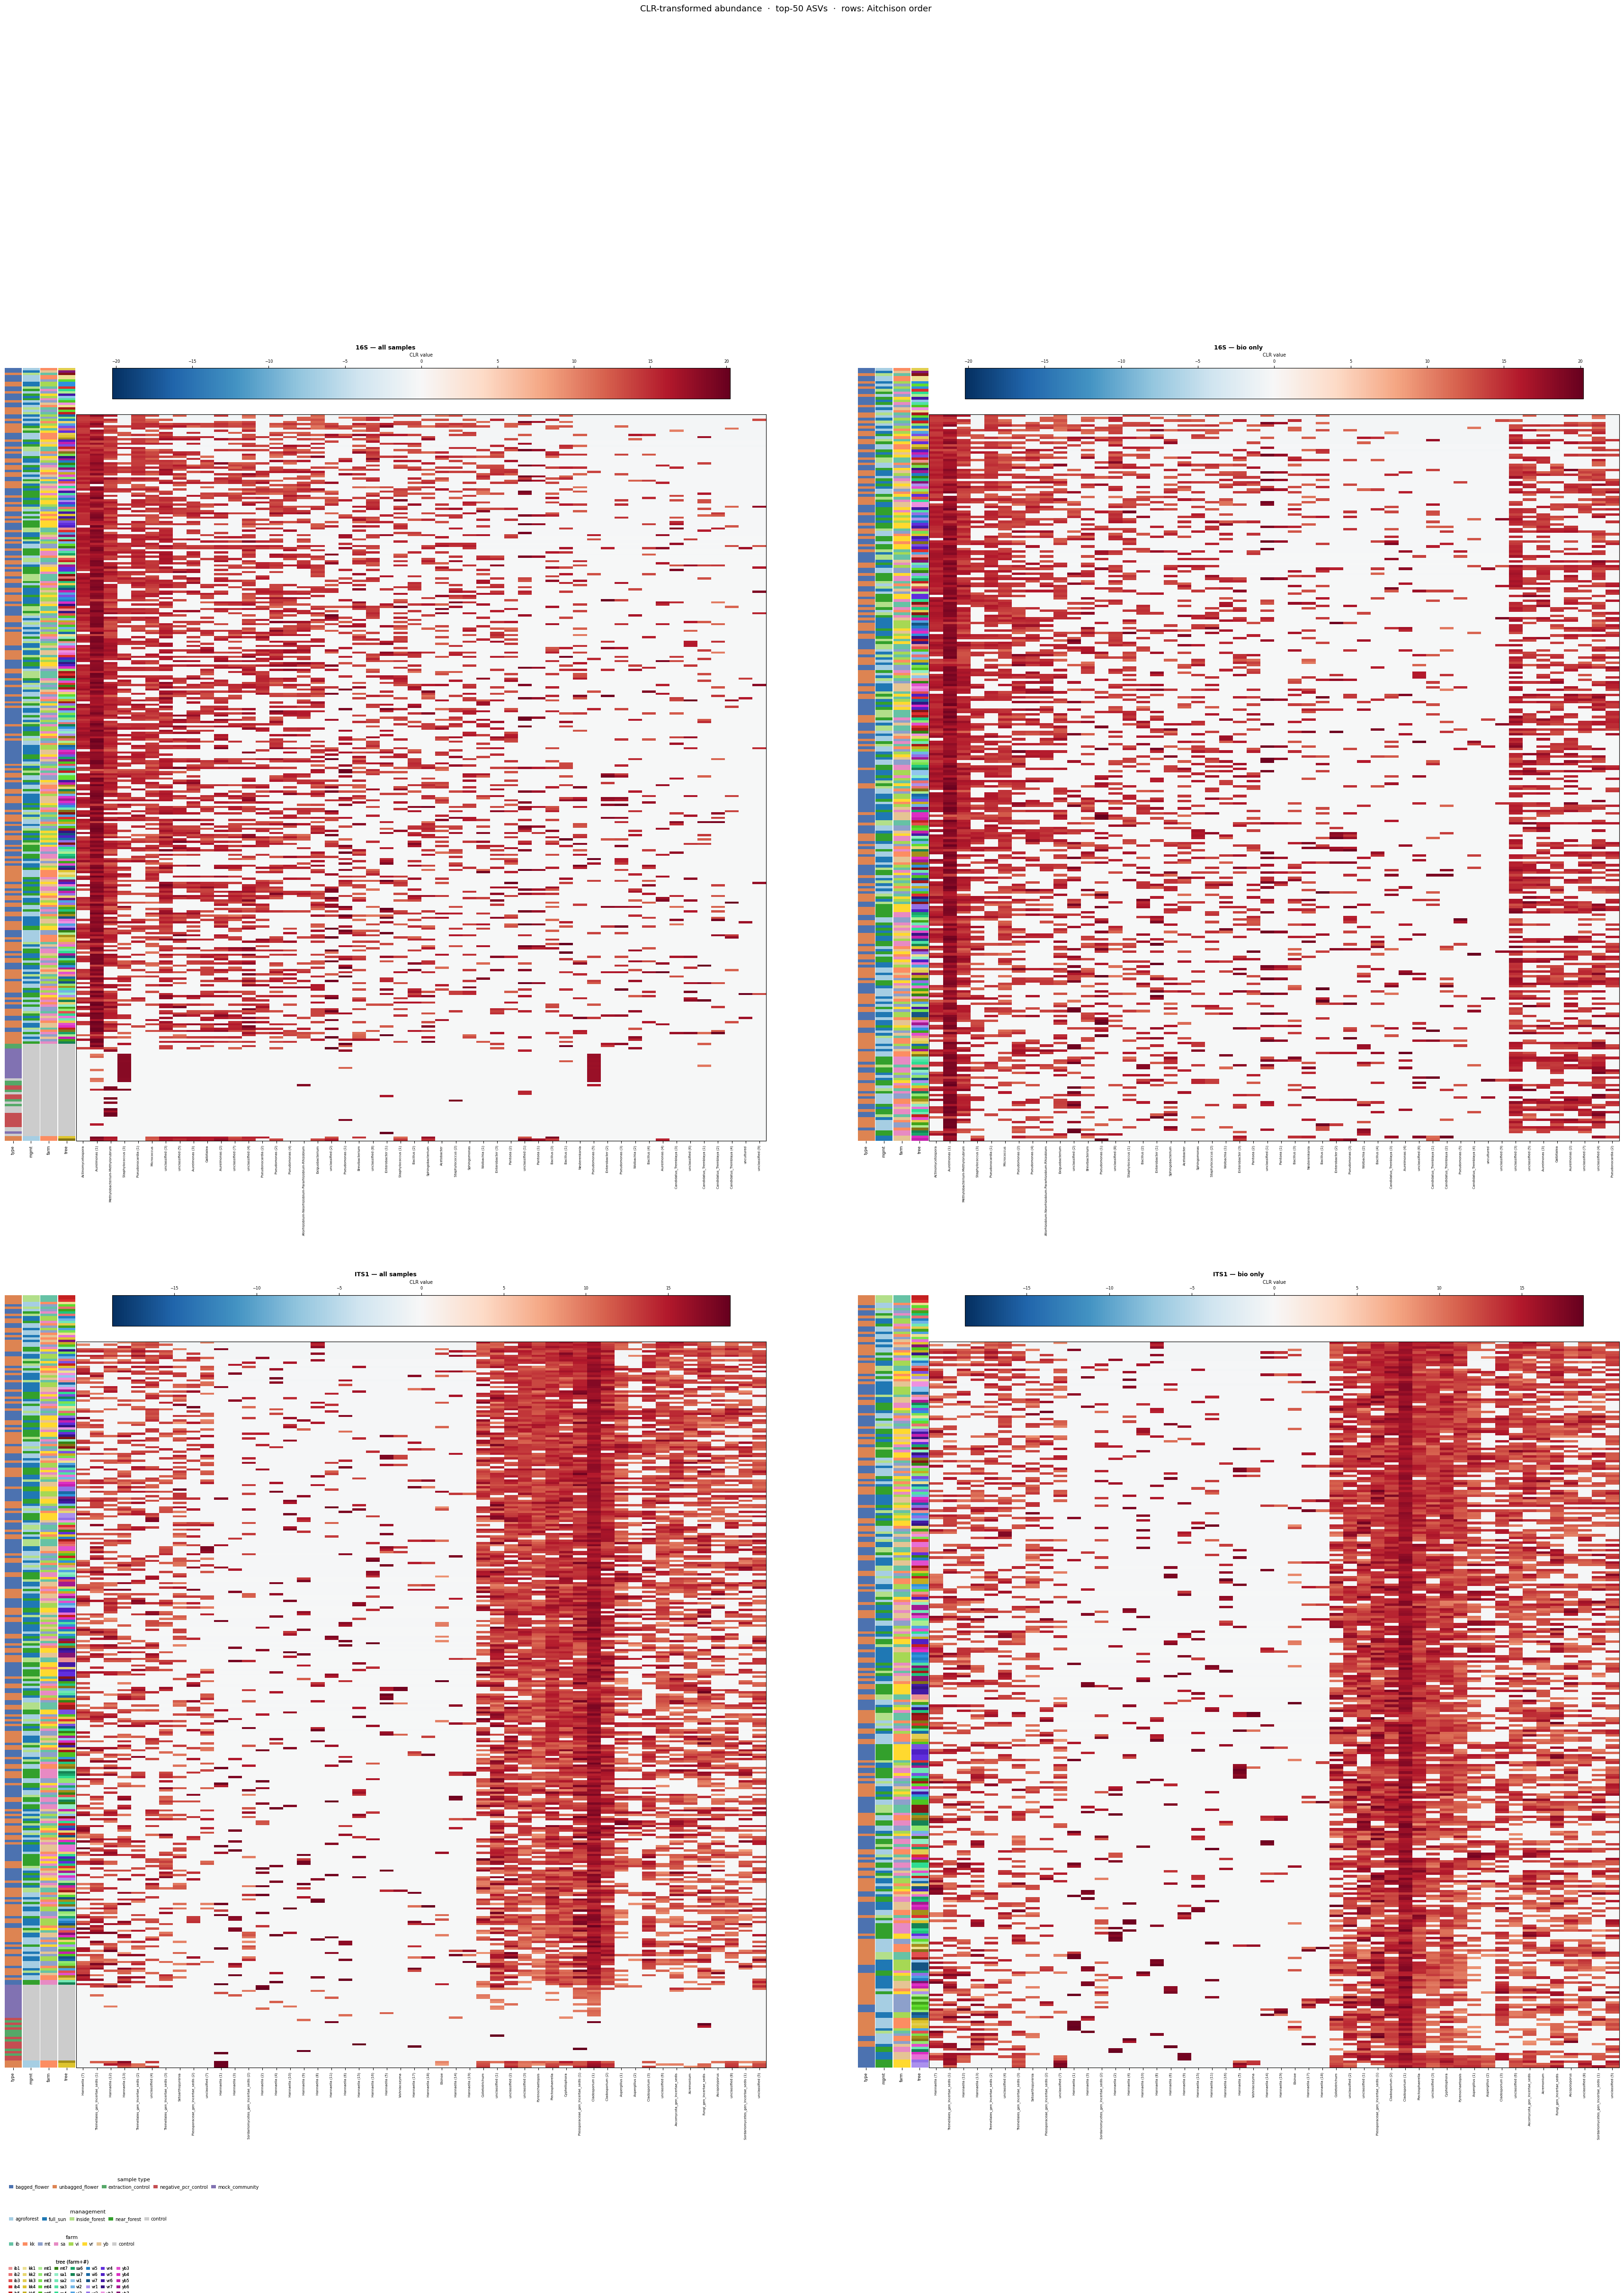

In [17]:
_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "clr", _ttl)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg)

_fig.suptitle("CLR-transformed abundance  ·  top-50 ASVs  ·  rows: Aitchison order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_02_clr.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()


### Panel 3 — Bray-Curtis dissimilarity matrix

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_03_bc.png


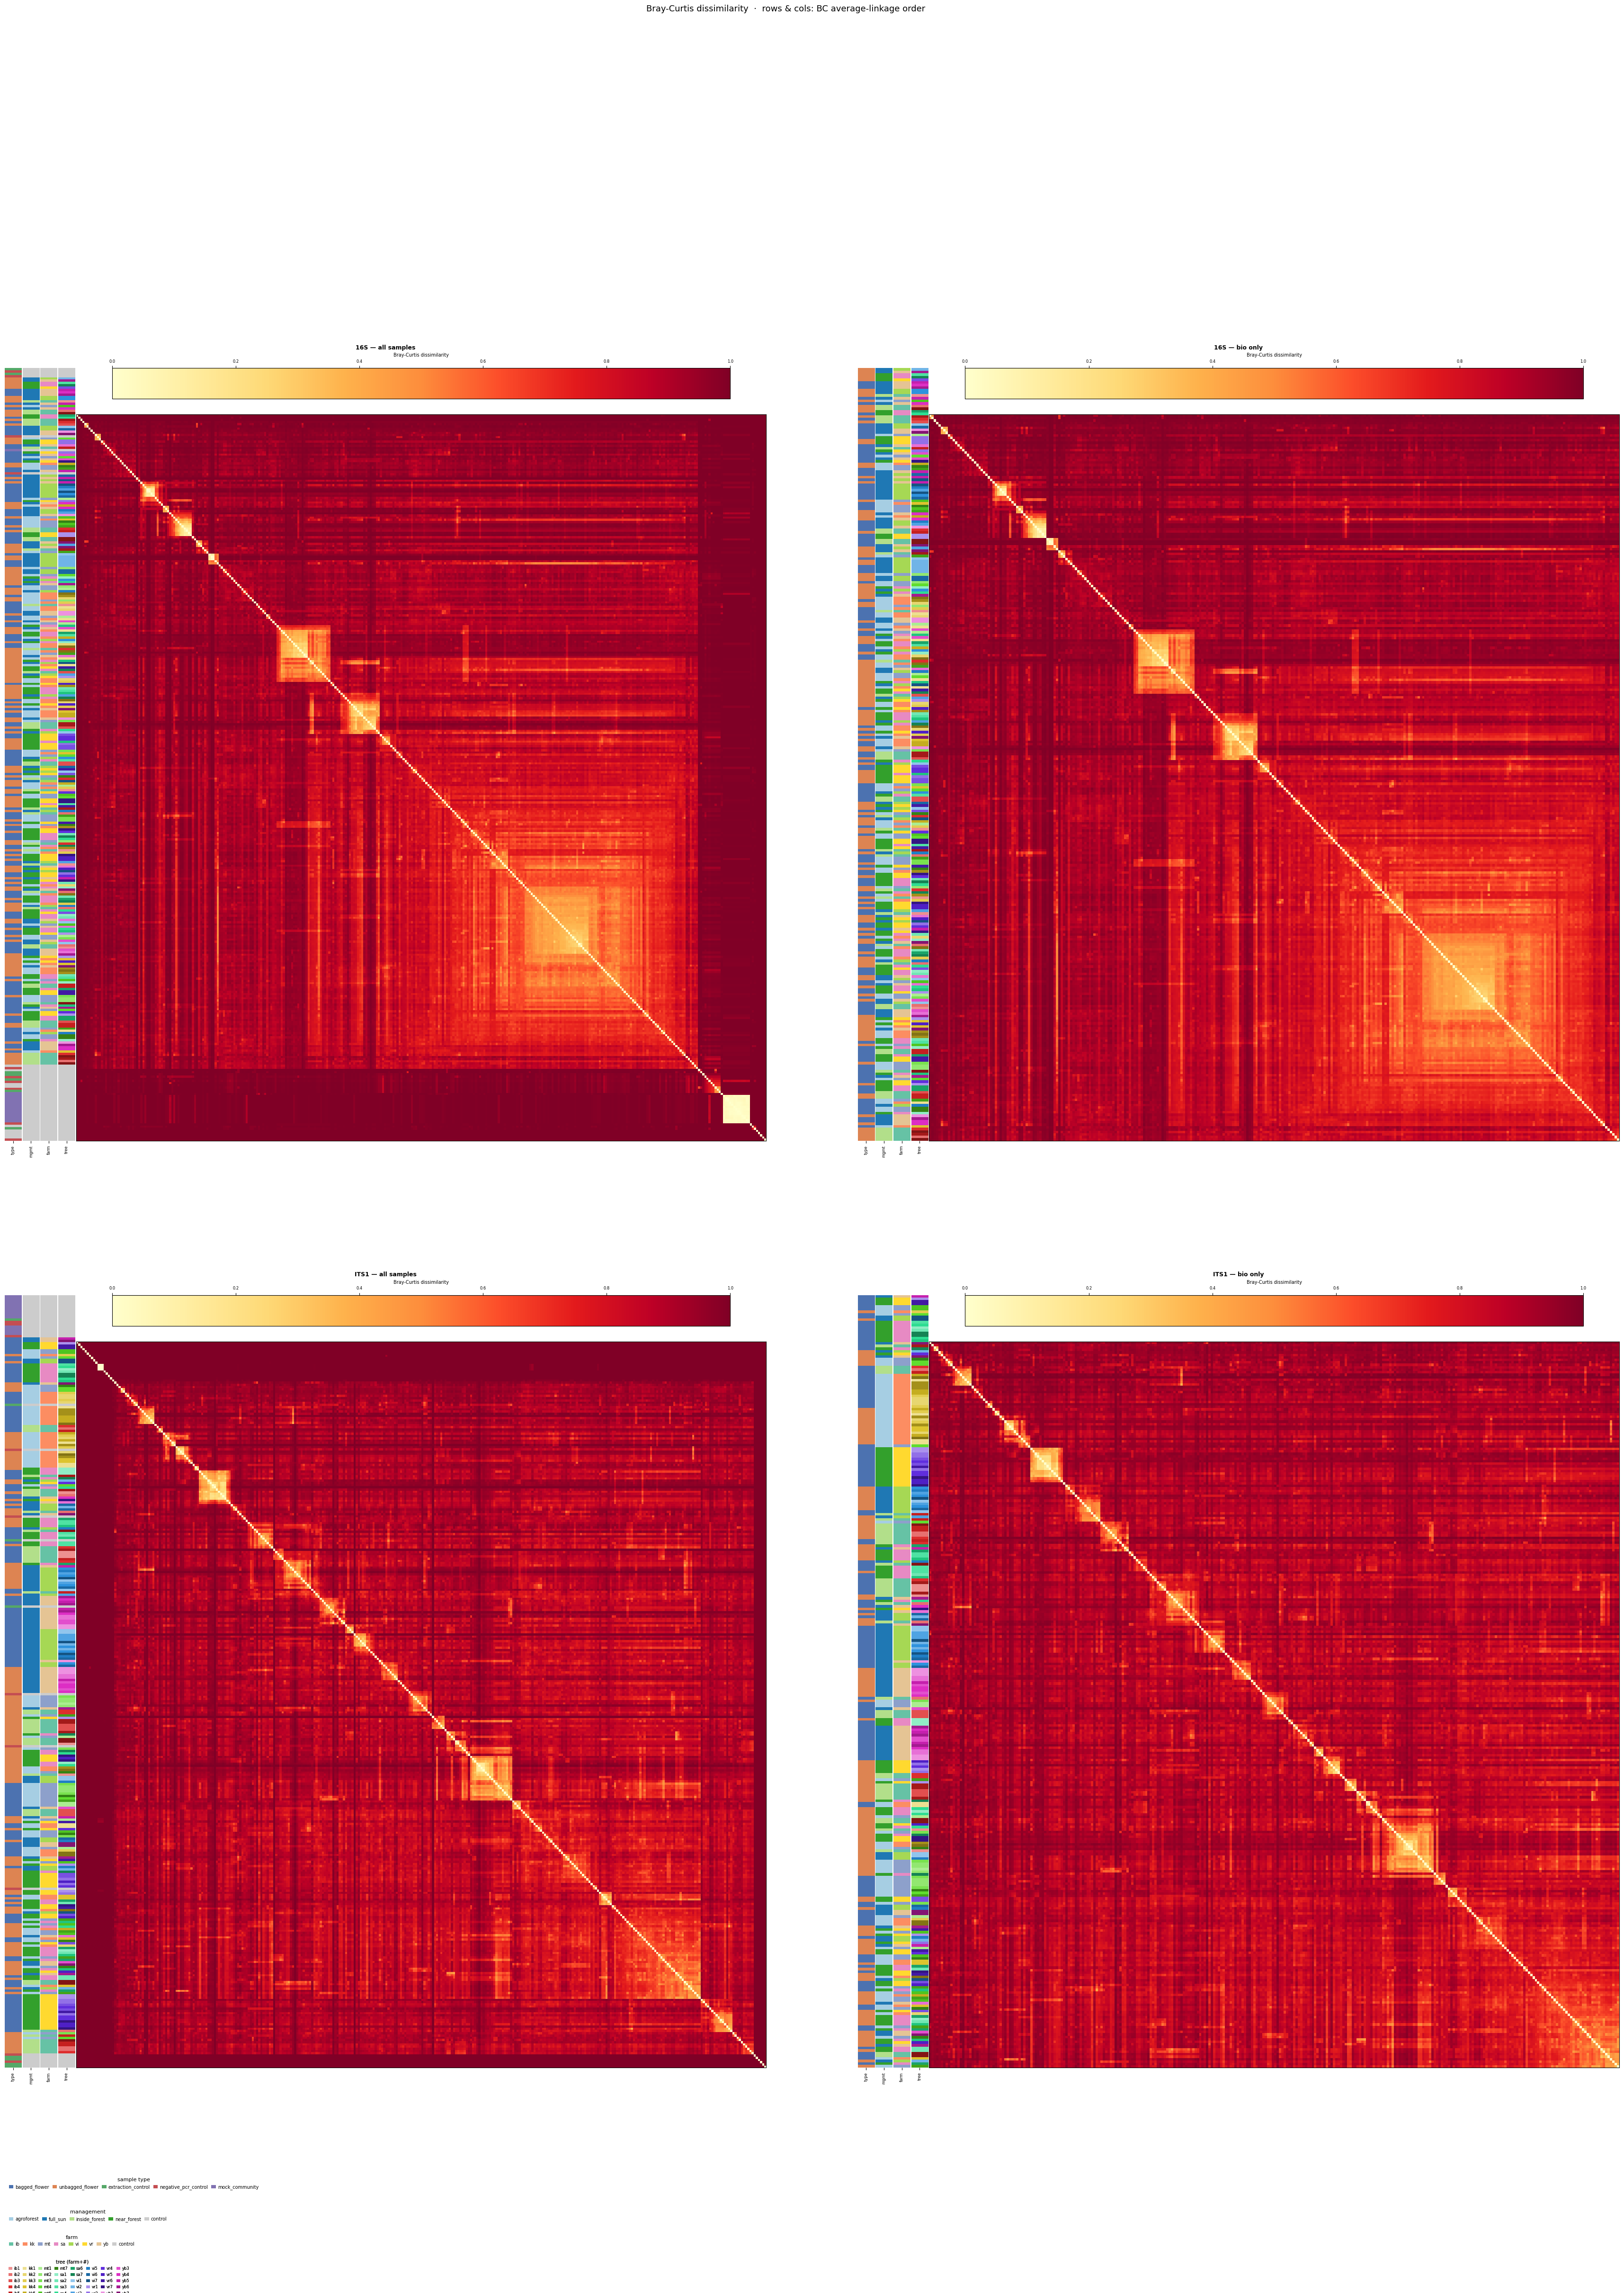

In [18]:
_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "bc", _ttl)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg)

_fig.suptitle("Bray-Curtis dissimilarity  ·  rows & cols: BC average-linkage order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_03_bc.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()


### Panel 4 — Aitchison distance matrix

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_04_aitchison.png


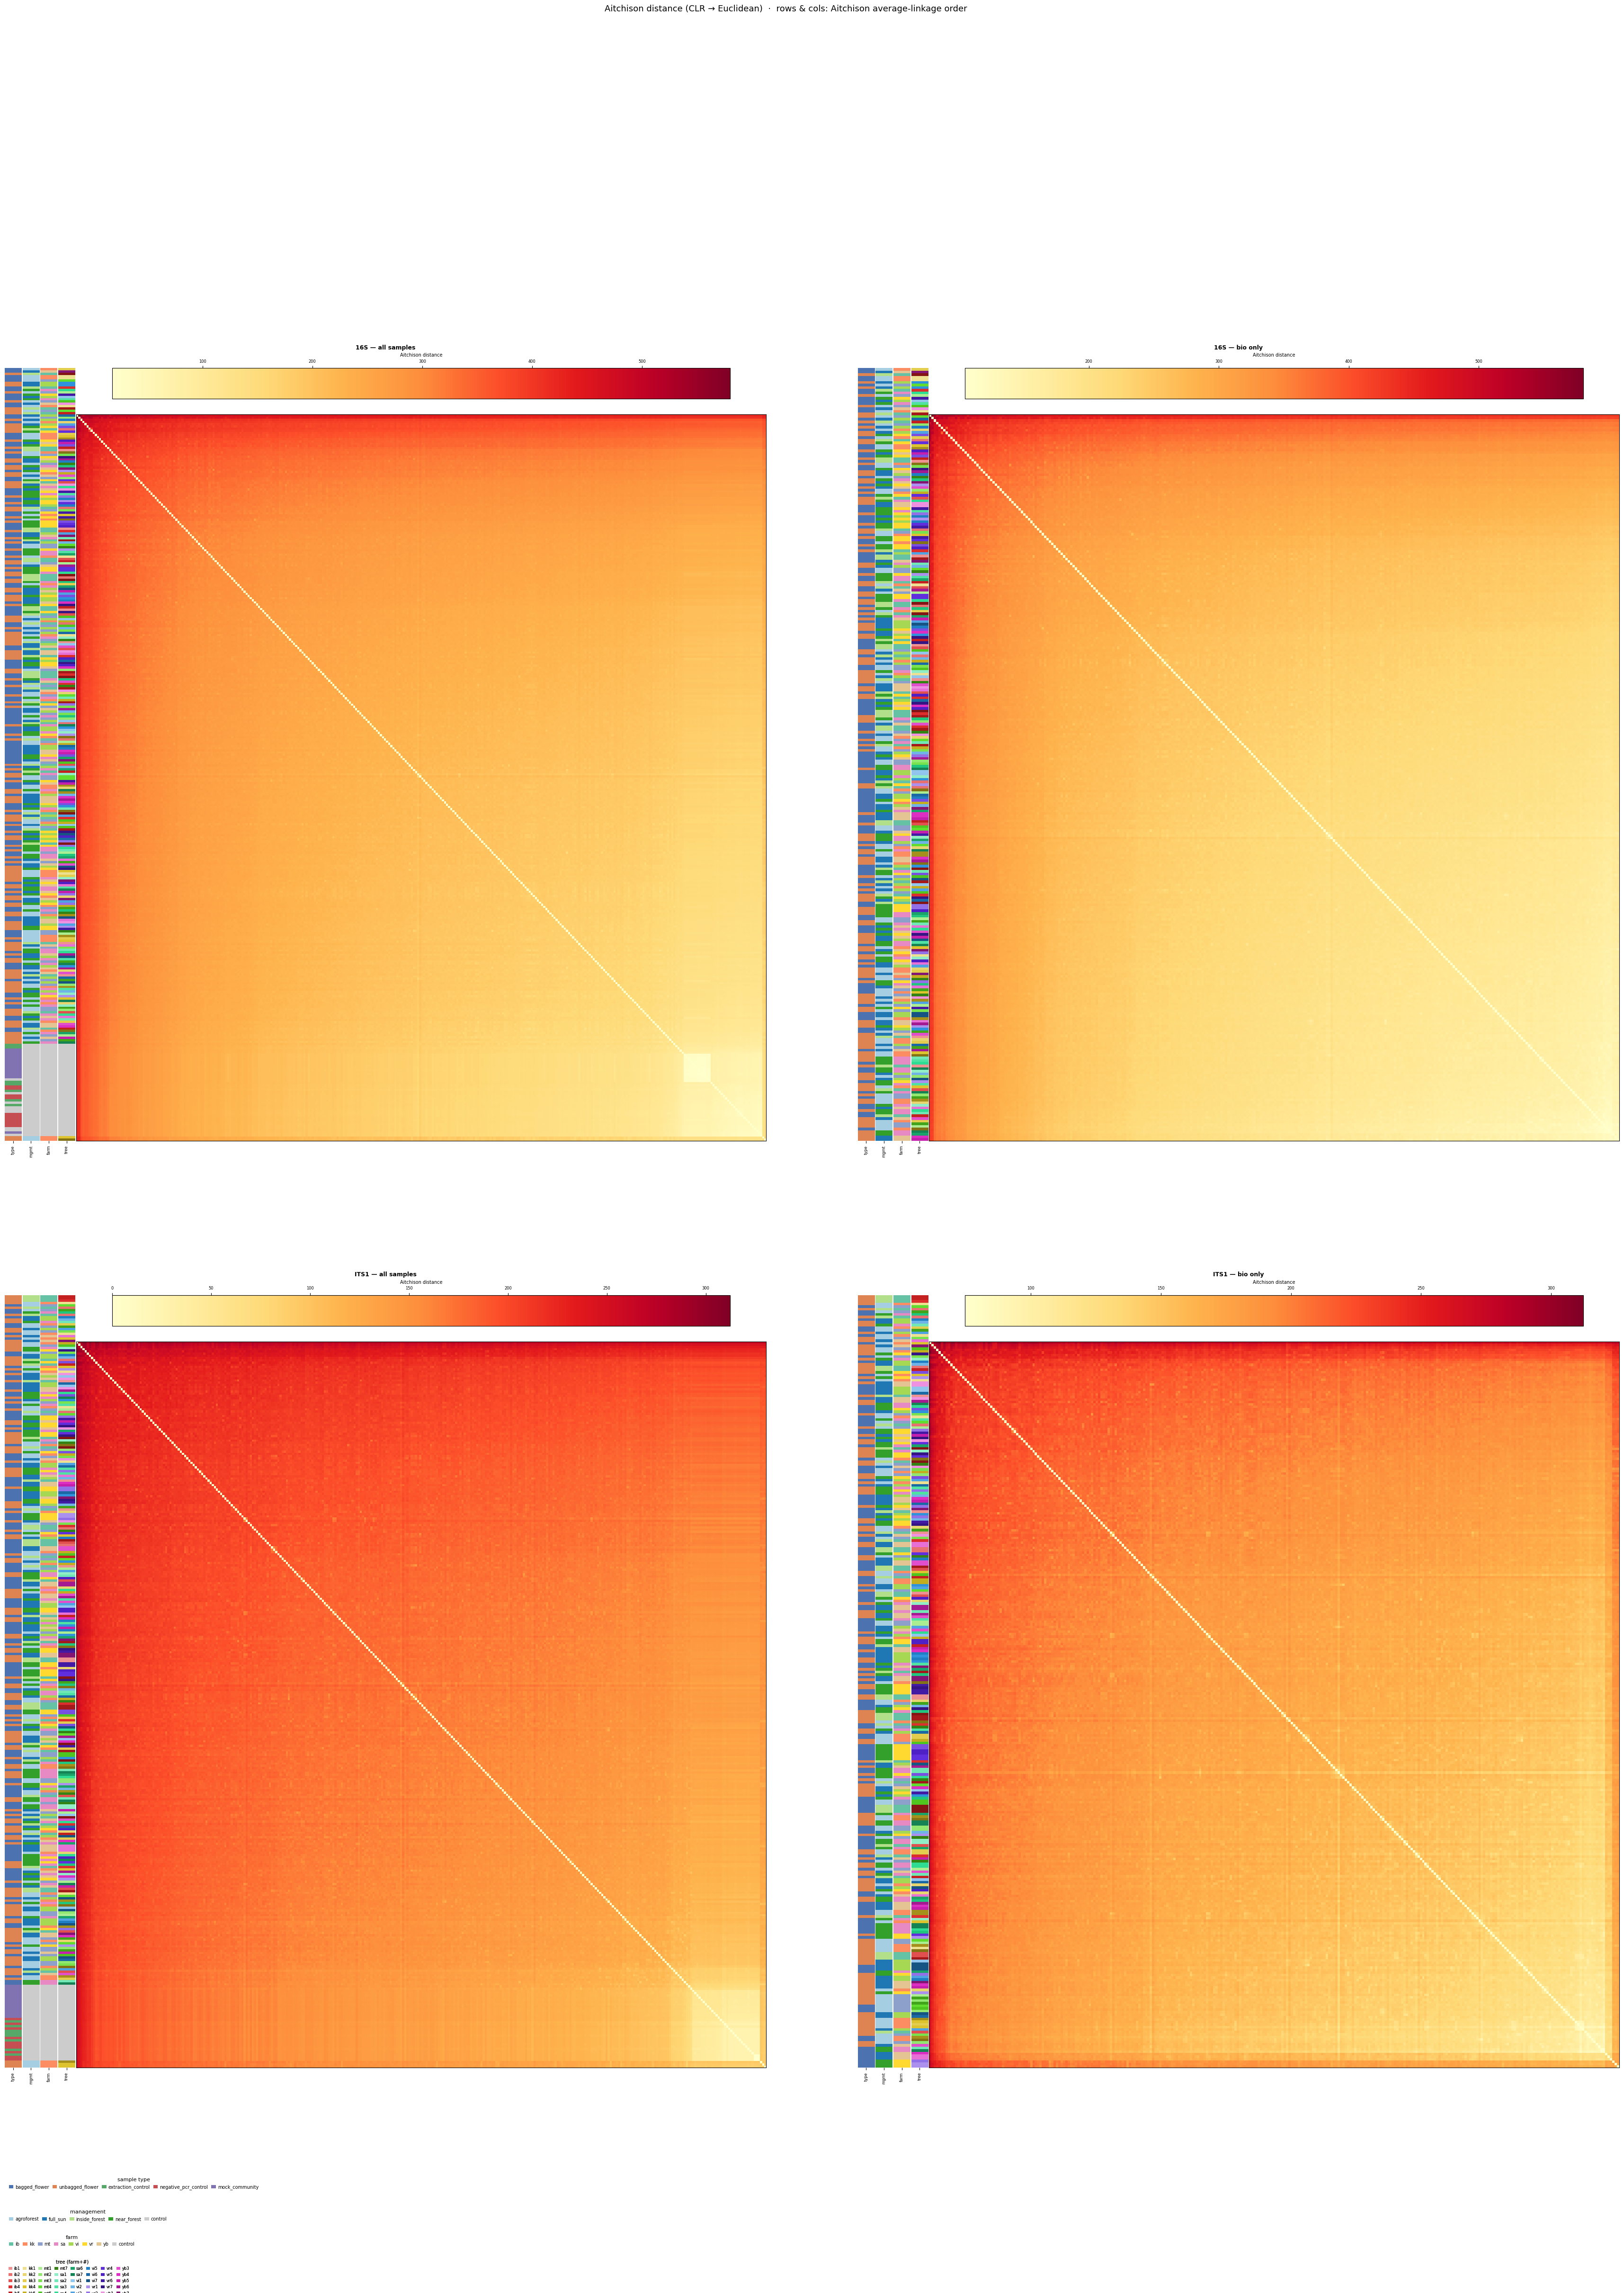

In [19]:
_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "aitchison", _ttl)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg)

_fig.suptitle("Aitchison distance (CLR → Euclidean)  ·  rows & cols: Aitchison average-linkage order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_04_aitchison.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()
